# N3 — Modelagem Preditiva de Atividade Sísmica Global**Disciplina:** Modelagem Preditiva, Avaliação e Rastreio de Experimentos  **Case:** Previsão da quantidade diária de terremotos (magnitude ≥ 2.5) com dados da [USGS Earthquake Hazards API](https://earthquake.usgs.gov/fdsnws/event/1/).---## Descrição do caseA atividade sísmica global é registrada continuamente por redes de monitoramento. Para proteção civil, seguradoras e operadores de infraestrutura, **antecipar picos de eventos** ajuda a:- Escalar equipes de resposta rápida- Revisar planos de contingência- Comunicar riscos ao público**Variável-alvo:** `quake_count` — número de terremotos por dia (agregação diária).  **Horizonte de previsão:** 14 dias (configurável).  **Fonte:** Mesmo repositório das avaliações N1/N2 (dashboard Streamlit + API USGS).> Execute todas as células em ordem. Requisitos: `pip install -r requirements.txt`

In [1]:
# Configuração inicial
%matplotlib inline

import warnings
from pathlib import Path
from IPython.display import Image, display, Markdown

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# Importa pipeline do módulo reprodutível
import n3_modelagem_preditiva as n3
from n3_modelagem_preditiva import (
    TARGET_COL, TRAIN_RATIO, FORECAST_HORIZON, WANDB_PROJECT,
    TABELAS_DIR, GRAFICOS_DIR,
    carregar_eventos_usgs, construir_serie_diaria,
    etapa1_auditoria, etapa2_features, etapa3_baselines,
    etapa4_estacionariedade, etapa5_modelos, etapa5_aic_sarima,
    etapa6_overfitting_demo, etapa8_walk_forward, etapa9_previsao_final,
    df_to_markdown, calcular_metricas,
)

n3.set_notebook_mode(True)
n3.TABELAS_DIR.mkdir(parents=True, exist_ok=True)
n3.GRAFICOS_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto wandb:", WANDB_PROJECT)
print("Saídas em:", n3.BASE_OUTPUT.resolve())

Projeto wandb: earthquake-n3-predictive
Saídas em: /workspace/outputs_n3


---## 1. Auditoria e EDAConferência estrutural da série temporal: dimensão, período, frequência, nulos, gaps, outliers (IQR) e imputação documentada.

In [2]:
df_eventos = carregar_eventos_usgs()
daily = construir_serie_diaria(df_eventos)
daily.to_csv(TABELAS_DIR / "00_serie_diaria.csv")

print(f"Dimensão: {daily.shape[0]} dias × {daily.shape[1]} colunas")
print(f"Período: {daily.index.min().date()} → {daily.index.max().date()}")
print(f"Frequência inferida: {pd.infer_freq(daily.index) or 'D (diária)'}")

diagnostico = etapa1_auditoria(daily)
display(diagnostico)

with open(TABELAS_DIR / "01_impacto_qualidade.txt") as f:
    display(Markdown(f.read()))

Coletando dados da API USGS...


Dimensão: 180 dias × 5 colunas
Período: 2018-01-01 → 2018-06-29
Frequência inferida: D

ETAPA 1 — Revisão e auditoria da série temporal
Dimensão: (180, 5)
Período: 2018-01-01 → 2018-06-29
Frequência: D

Diagnóstico de qualidade:
       coluna  nulos  duplicatas_indice  gaps_datas  outliers_iqr                                 tratamento_outliers
  quake_count      0                  0           0            23 manter (eventos sísmicos extremos são informativos)
avg_magnitude      0                  0           0             7 manter (eventos sísmicos extremos são informativos)
max_magnitude      0                  0           0             7 manter (eventos sísmicos extremos são informativos)
    avg_depth      0                  0           0             0 manter (eventos sísmicos extremos são informativos)
tsunami_count      0                  0           0            43 manter (eventos sísmicos extremos são informativos)


,coluna,nulos,duplicatas_indice,gaps_datas,outliers_iqr,tratamento_outliers
0,quake_count,0,0,0,23,manter (eventos sísmicos extremos são informat...
1,avg_magnitude,0,0,0,7,manter (eventos sísmicos extremos são informat...
2,max_magnitude,0,0,0,7,manter (eventos sísmicos extremos são informat...
3,avg_depth,0,0,0,0,manter (eventos sísmicos extremos são informat...
4,tsunami_count,0,0,0,43,manter (eventos sísmicos extremos são informat...


Gaps e nulos em médias contínuas foram tratados por interpolação temporal; contagens ausentes viraram zero porque 'nenhum evento' é informação válida. Outliers em quake_count refletem dias de alta atividade sísmica real — removê-los distortionaria a modelagem de picos. Problemas de qualidade afetam principalmente variáveis derivadas (médias) em dias sem eventos; a variável-alvo quake_count permanece consistente após asfreq('D').

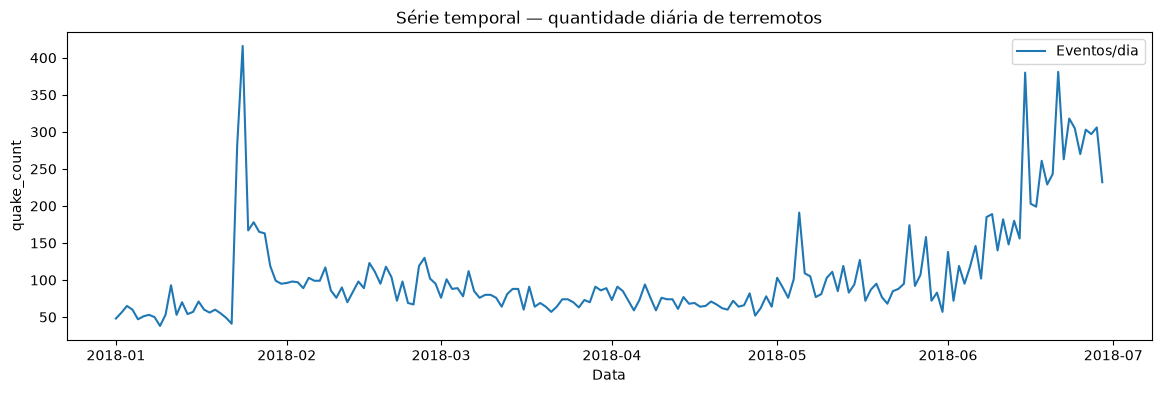

,quake_count,avg_magnitude,max_magnitude
count,180.00,180.00,180.00
mean,107.63,3.59,5.65
std,68.30,0.27,0.54
min,38.00,2.91,4.80
25%,69.00,3.46,5.29
50%,86.00,3.61,5.60
75%,111.00,3.78,5.90
max,416.00,4.30,7.90


In [3]:
# EDA — série temporal e estatísticas descritivas
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily[TARGET_COL], label="Eventos/dia")
ax.set_title("Série temporal — quantidade diária de terremotos")
ax.set_xlabel("Data")
ax.set_ylabel("quake_count")
ax.legend()
plt.show()

display(daily[[TARGET_COL, "avg_magnitude", "max_magnitude"]].describe().round(2))

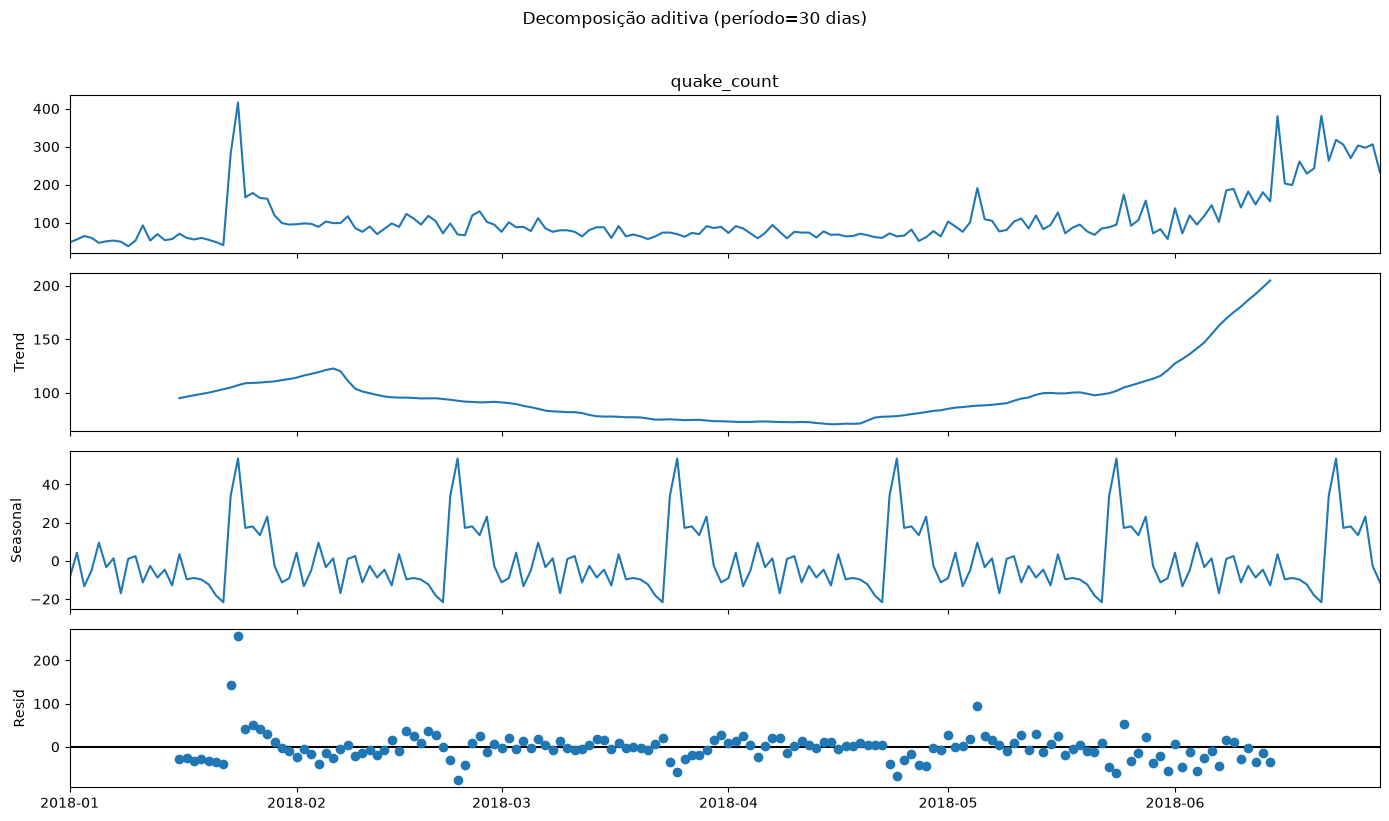

In [4]:
# Decomposição (tendência + sazonalidade + resíduo)
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily[TARGET_COL].ffill(), model="additive", period=30)
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Decomposição aditiva (período=30 dias)", y=1.02)
plt.tight_layout()
plt.savefig(GRAFICOS_DIR / "04_decomposicao.png", dpi=200, bbox_inches="tight")
plt.show()

---## 2. Engenharia de atributosLags autorregressivos, médias móveis, encoding cíclico (seno/cosseno) e split temporal 80/20 (sem embaralhar).

In [5]:
df_model, train, test, feature_cols = etapa2_features(daily)

hipoteses = pd.read_csv(TABELAS_DIR / "02_hipoteses_features.csv")
display(Markdown("### Tabela de hipóteses das features"))
display(hipoteses)

print(f"Treino: {len(train)} obs | Teste: {len(test)} obs")
df_model.head()


ETAPA 2 — Engenharia de atributos
Dataset final: (173, 14) | Treino: 138 | Teste: 35

Hipóteses das features:
                feature                                                                             hipotese
                   lag1 A contagem de hoje depende fortemente do dia anterior (persistência de curto prazo).
                   lag2                         Memória de dois dias captura sequências de enxames sísmicos.
                    mm7                     Média móvel de 7 dias suaviza ruído e reflete tendência semanal.
        mes_sin/mes_cos                        Encoding cíclico modela sazonalidade anual de forma contínua.
dia_sem_sin/dia_sem_cos                      Padrões semanais (relato/registro) podem influenciar contagens.
          avg_magnitude              Dias com magnitudes médias altas tendem a ter mais eventos registrados.


### Tabela de hipóteses das features

,feature,hipotese
0,lag1,A contagem de hoje depende fortemente do dia a...
1,lag2,Memória de dois dias captura sequências de enx...
2,mm7,Média móvel de 7 dias suaviza ruído e reflete ...
3,mes_sin/mes_cos,Encoding cíclico modela sazonalidade anual de ...
4,dia_sem_sin/dia_sem_cos,Padrões semanais (relato/registro) podem influ...
5,avg_magnitude,Dias com magnitudes médias altas tendem a ter ...


Treino: 138 obs | Teste: 35 obs


,quake_count,lag1,lag2,lag7,mm7,mm14,mes_sin,mes_cos,dia_sem_sin,dia_sem_cos,avg_magnitude,max_magnitude,avg_depth,tsunami_count
date,,,,,,,,,,,,,,
2018-01-08,50,53.0,51.0,48.0,54.571429,53.750000,0.5,0.866025,0.000000,1.000000,3.947000,5.0,91.874800,0
2018-01-09,38,50.0,53.0,56.0,52.000000,52.000000,0.5,0.866025,0.781831,0.623490,3.949211,5.8,72.361316,0
2018-01-10,53,38.0,50.0,65.0,50.285714,52.100000,0.5,0.866025,0.974928,-0.222521,3.982075,7.5,69.695849,1
2018-01-11,93,53.0,38.0,60.0,55.000000,55.818182,0.5,0.866025,0.433884,-0.900969,4.002043,6.0,61.079516,0
2018-01-12,53,93.0,53.0,47.0,55.857143,55.583333,0.5,0.866025,-0.433884,-0.900969,4.007925,4.9,75.178340,0


---## 3. Baselines — régua de desempenhoReferências mínimas: **persistência (Naïve)** e **média móvel de 7 dias**.

In [6]:
baselines, preds_baselines = etapa3_baselines(daily, train, test)

display(Markdown("### Tabela comparativa — Baselines"))
display(baselines.round(2))


ETAPA 3 — Baselines e régua de desempenho


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Tracking run with wandb version 0.28.0


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /workspace/wandb/offline-run-20260625_152422-cgp9wje8
wandb: View this run in the terminal with `wandb leet`


wandb: 
wandb: Run history:
wandb:  teste/mae ▁
wandb: teste/mape ▁
wandb: teste/rmse ▁
wandb: 
wandb: Run summary:
wandb:  teste/mae 52.74286
wandb: teste/mape 32.19593
wandb: teste/rmse 71.54898
wandb: 


...

wandb: You can sync this run to the cloud by running:
wandb: wandb sync /workspace/wandb/offline-run-20260625_152423-i2ujzgdj


wandb: Find logs at: ./wandb/offline-run-20260625_152423-i2ujzgdj/logs


                modelo       mae      rmse      mape
 baseline_persistencia 52.742857 71.548984 32.195929
baseline_media_movel_7 35.036735 54.726513 20.241031


### Tabela comparativa — Baselines

,modelo,mae,rmse,mape
0,baseline_persistencia,52.74,71.55,32.20
1,baseline_media_movel_7,35.04,54.73,20.24


---## 4. Estacionariedade, ACF/PACF e evidênciasTestes ADF/KPSS, gráficos ACF/PACF e tabela de evidências para escolha de ordens (p, d, q).


ETAPA 4 — Estacionariedade, ACF/PACF e evidências


             serie teste  estatistica      p_valor    interpretacao
          original   ADF    -2.047112 2.663057e-01 não estacionária
          original  KPSS     0.693489 1.413732e-02 não estacionária
diferenciada (d=1)   ADF    -8.454404 1.629535e-13     estacionária

Sugestão ACF/PACF: p≈1-2 (PACF corta cedo), q≈1-2 (ACF decai), sazonalidade ~30 dias.


### Tabela de evidências — estacionariedade

,serie,teste,estatistica,p_valor,interpretacao
0,original,ADF,-2.047112,2.663057e-01,não estacionária
1,original,KPSS,0.693489,1.413732e-02,não estacionária
2,diferenciada (d=1),ADF,-8.454404,1.629535e-13,estacionária


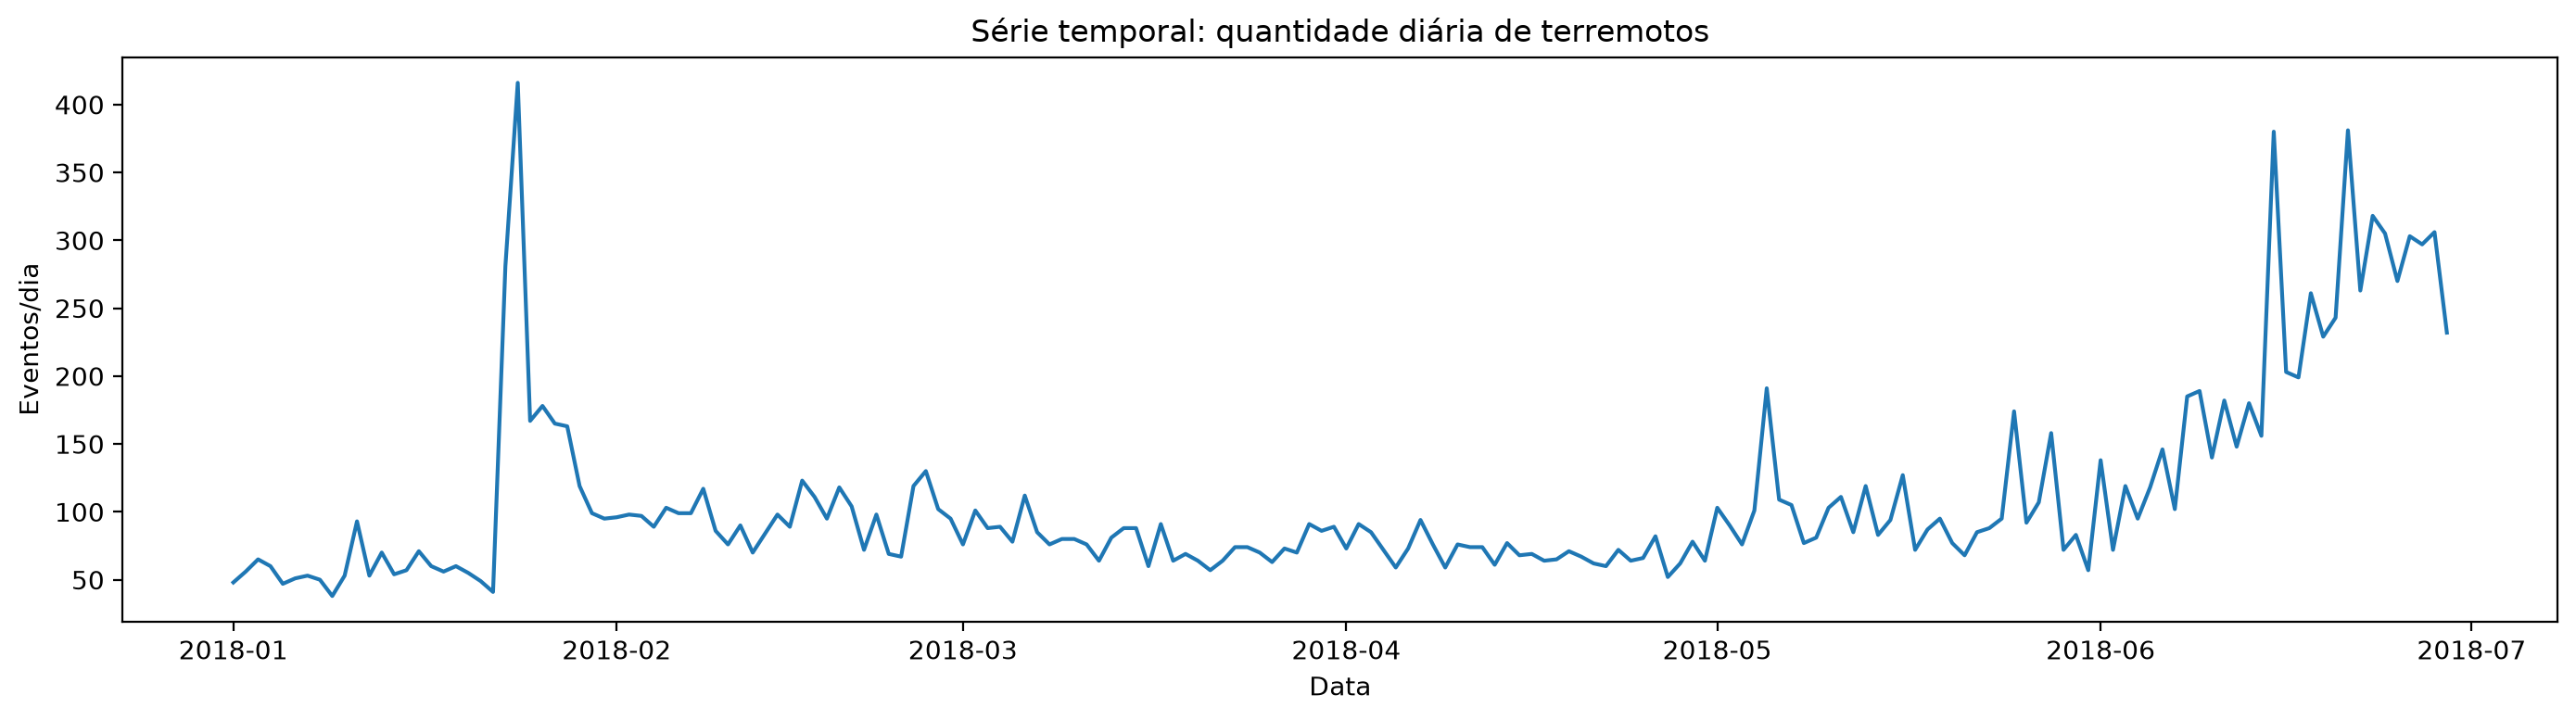

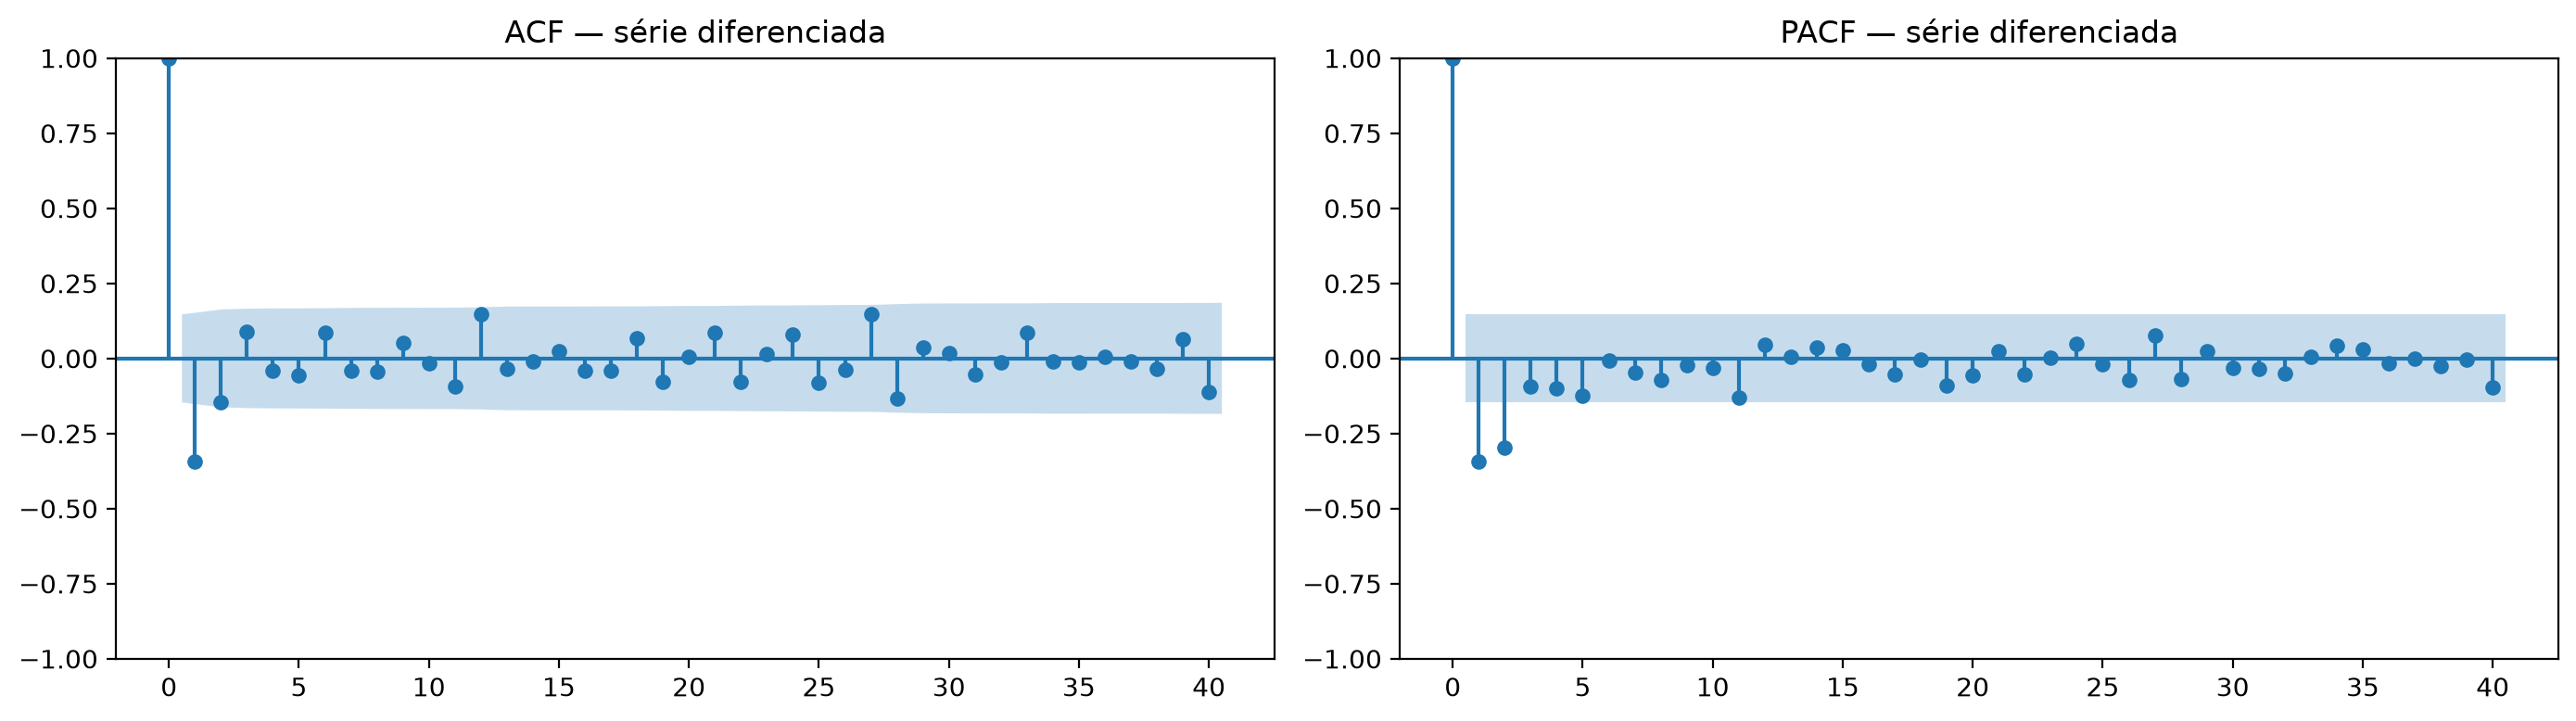

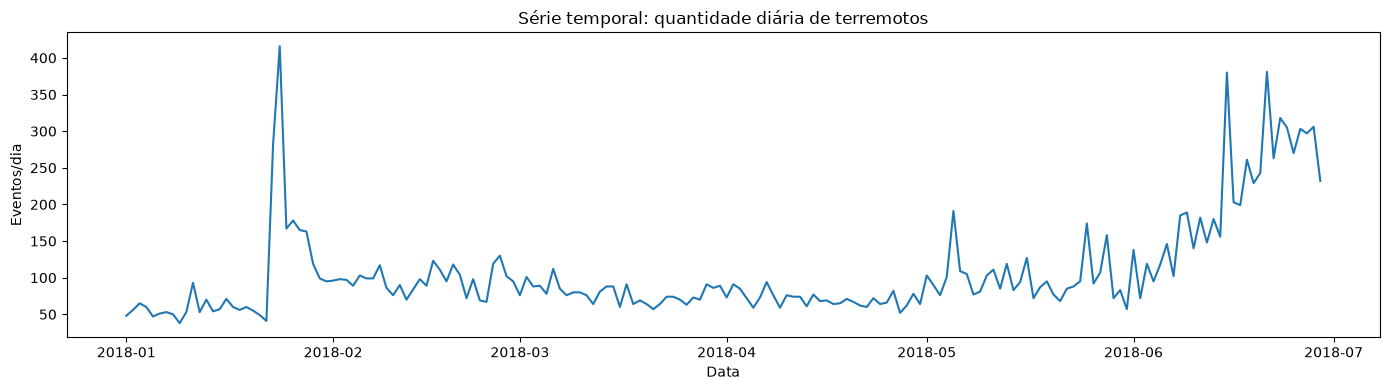

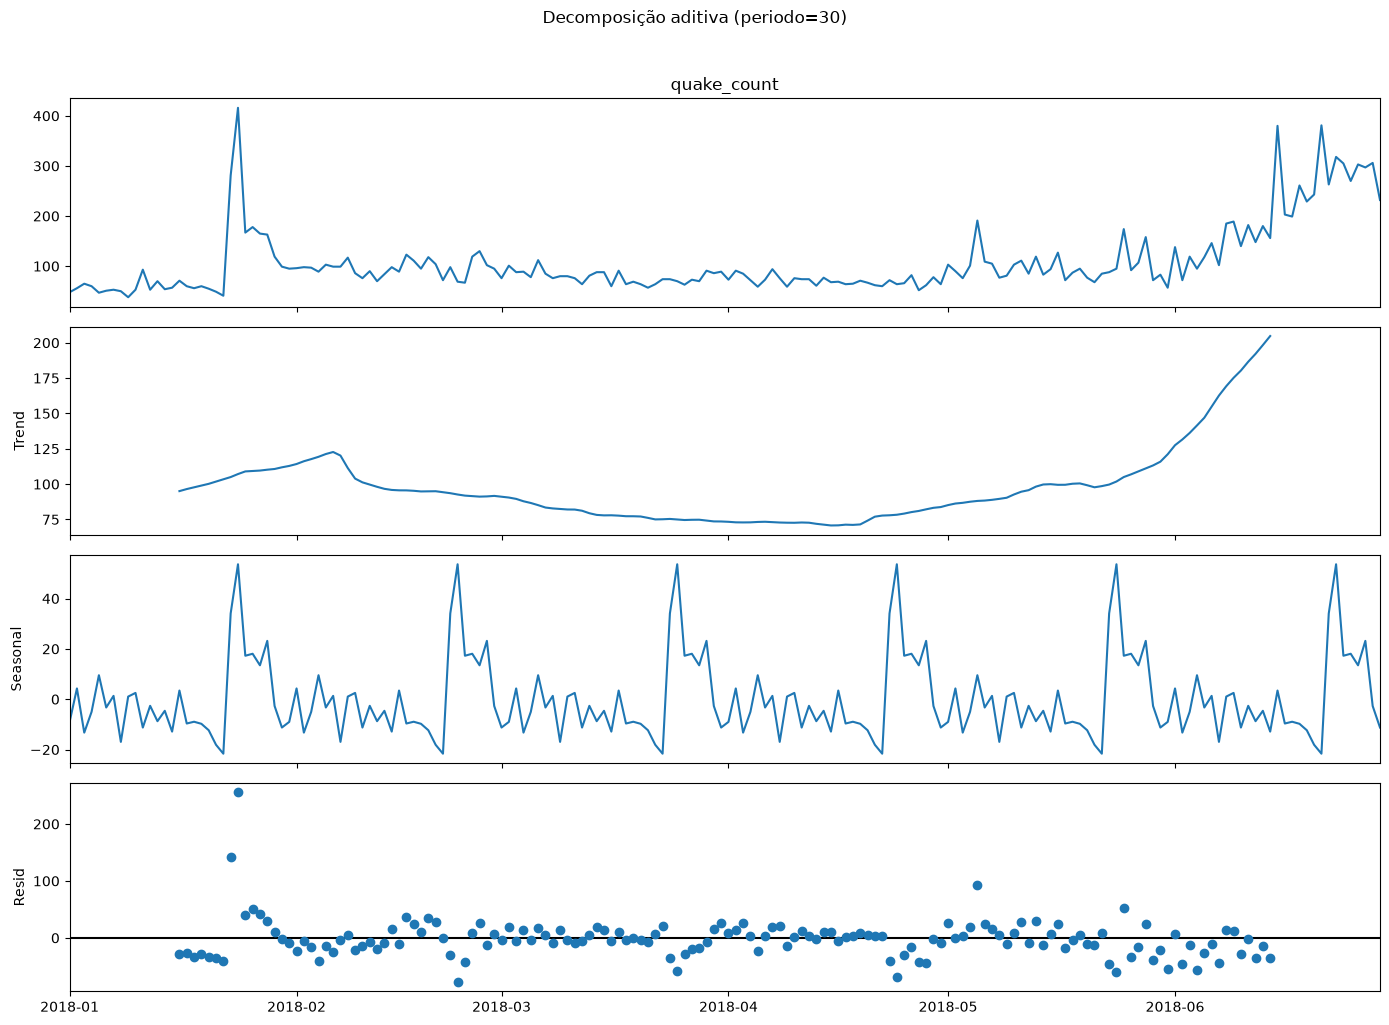

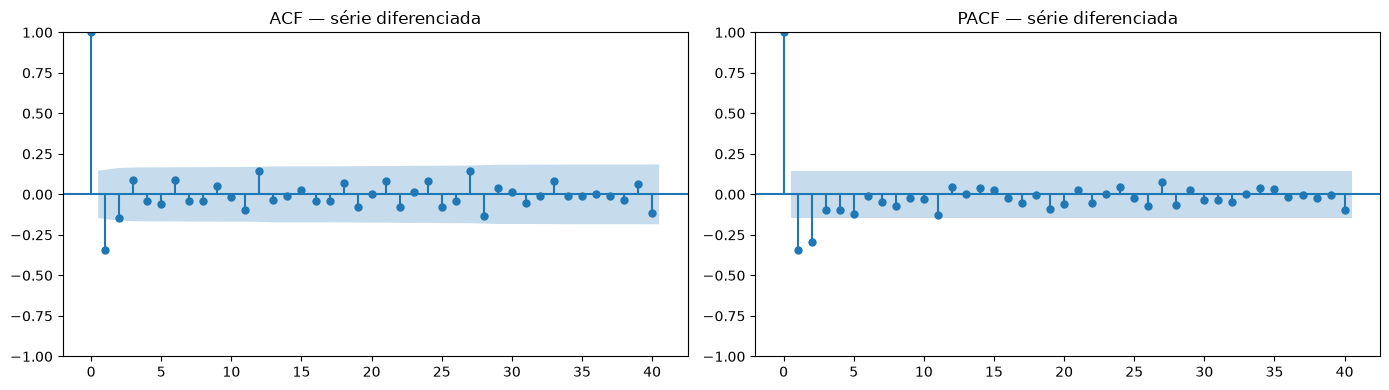

In [7]:
_, evidencias = etapa4_estacionariedade(daily)

display(Markdown("### Tabela de evidências — estacionariedade"))
display(evidencias)

# Exibe gráficos salvos
for img in ["04_serie_temporal.png", "04_acf_pacf.png"]:
    p = GRAFICOS_DIR / img
    if p.exists():
        display(Image(filename=str(p), width=900))

---## 5. Modelagem preditiva (3 famílias)| Modelo | Família ||--------|---------|| SARIMA | ARIMA/ARIMAX/SARIMAX || Holt-Winters | Suavização exponencial || Random Forest | ML moderno com features derivadas |


ETAPA 6 — Hiperparâmetros e AIC (SARIMA)


    order seasonal_order        aic        bic
(1, 1, 1)  (2, 0, 1, 30) 684.032869 698.017269
(1, 1, 2)  (1, 0, 1, 30) 925.922436 941.788781
(2, 1, 2)  (1, 0, 1, 30) 927.910435 946.421172
(1, 1, 1)  (0, 0, 1, 30) 930.978934 941.594776
(1, 1, 1)  (1, 0, 1, 30) 932.694452 945.964254
(2, 1, 1)  (1, 0, 1, 30) 934.686407 950.610169


### Tabela AIC — combinações SARIMA testadas

,order,seasonal_order,aic,bic
5,"(1, 1, 1)","(2, 0, 1, 30)",684.032869,698.017269
2,"(1, 1, 2)","(1, 0, 1, 30)",925.922436,941.788781
3,"(2, 1, 2)","(1, 0, 1, 30)",927.910435,946.421172
4,"(1, 1, 1)","(0, 0, 1, 30)",930.978934,941.594776
0,"(1, 1, 1)","(1, 0, 1, 30)",932.694452,945.964254
1,"(2, 1, 1)","(1, 0, 1, 30)",934.686407,950.610169



ETAPA 5 — Modelagem preditiva (3 famílias)

ETAPA 6 — Hiperparâmetros e AIC (SARIMA)


...

       modelo     order      seasonal        mae       rmse      mape
       sarima (1, 1, 1) (2, 0, 1, 30) 101.240969 129.126049 45.680075
 holt_winters       NaN           NaN  85.355566 108.044953 41.853440
random_forest       NaN           NaN  47.164234  67.756649 22.765842



Ljung-Box (random_forest): p-valor = 0.0000


### Métricas no conjunto de teste

,modelo,order,seasonal,mae,rmse,mape
0,sarima,"(1, 1, 1)","(2, 0, 1, 30)",101.24,129.13,45.68
1,holt_winters,NaN,NaN,85.36,108.04,41.85
2,random_forest,NaN,NaN,47.16,67.76,22.77



Modelo campeão (menor RMSE): random_forest


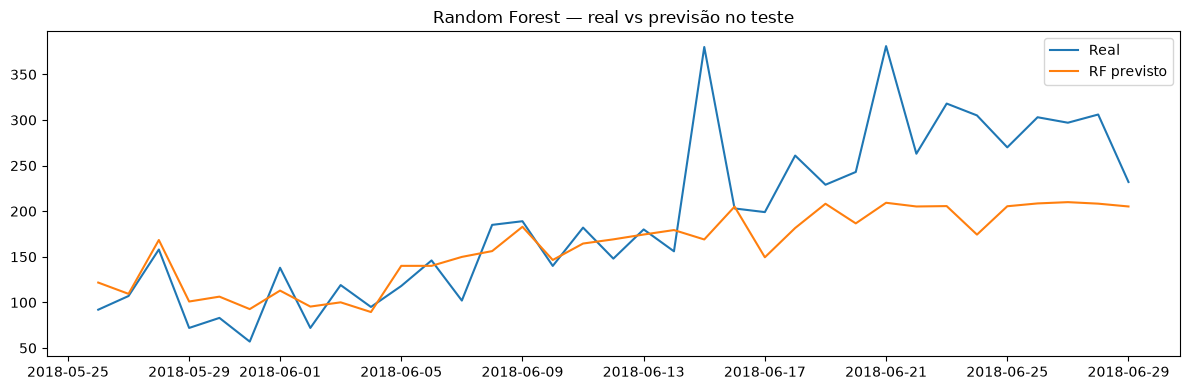

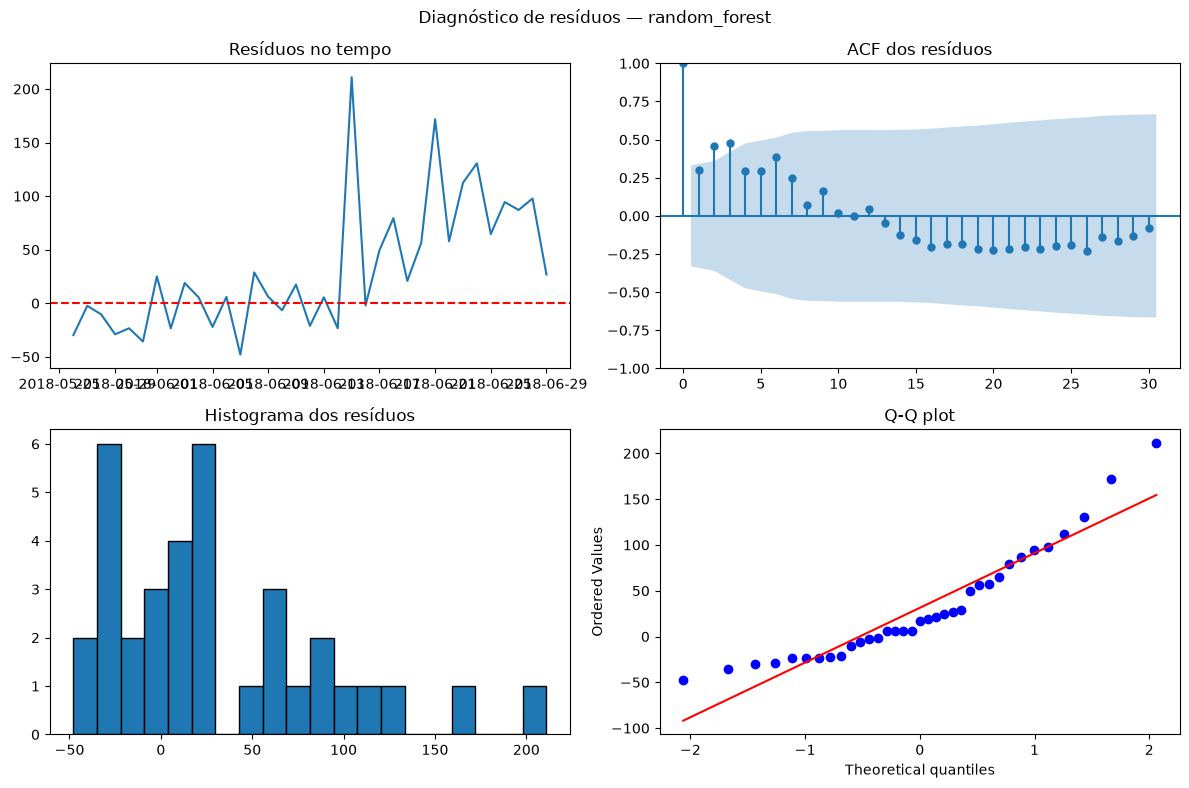

In [8]:
# Tabela AIC — seleção de hiperparâmetros SARIMA
y_train = daily.loc[train.index, TARGET_COL]
aic_table = etapa5_aic_sarima(y_train)

display(Markdown("### Tabela AIC — combinações SARIMA testadas"))
display(aic_table.sort_values("aic"))

modelos, campeao, pred_campeao = etapa5_modelos(daily, train, test, feature_cols)

display(Markdown("### Métricas no conjunto de teste"))
display(modelos.round(2))
print(f"\nModelo campeão (menor RMSE): {campeao}")

In [9]:
# Demonstração de overfitting
overfitting = etapa6_overfitting_demo(daily, train, test, feature_cols)
display(Markdown("### Overfitting — treino vs teste"))
display(overfitting.round(2))


ETAPA 6 — Demonstração de overfitting (Random Forest)


             modelo  max_depth  n_features  mae_treino  rmse_treino  mae_teste  rmse_teste
  rf_simples_depth3          3           6   11.750320    17.600946  85.486068  109.050226
rf_complexo_depth20         20          25    5.907823    11.615014  63.897143   89.366967


### Overfitting — treino vs teste

,modelo,max_depth,n_features,mae_treino,rmse_treino,mae_teste,rmse_teste
0,rf_simples_depth3,3,6,11.75,17.60,85.49,109.05
1,rf_complexo_depth20,20,25,5.91,11.62,63.90,89.37


---## 6. Diagnóstico de resíduos (modelo campeão)Gráficos de resíduos no tempo, ACF, histograma, Q-Q plot e teste de Ljung-Box.

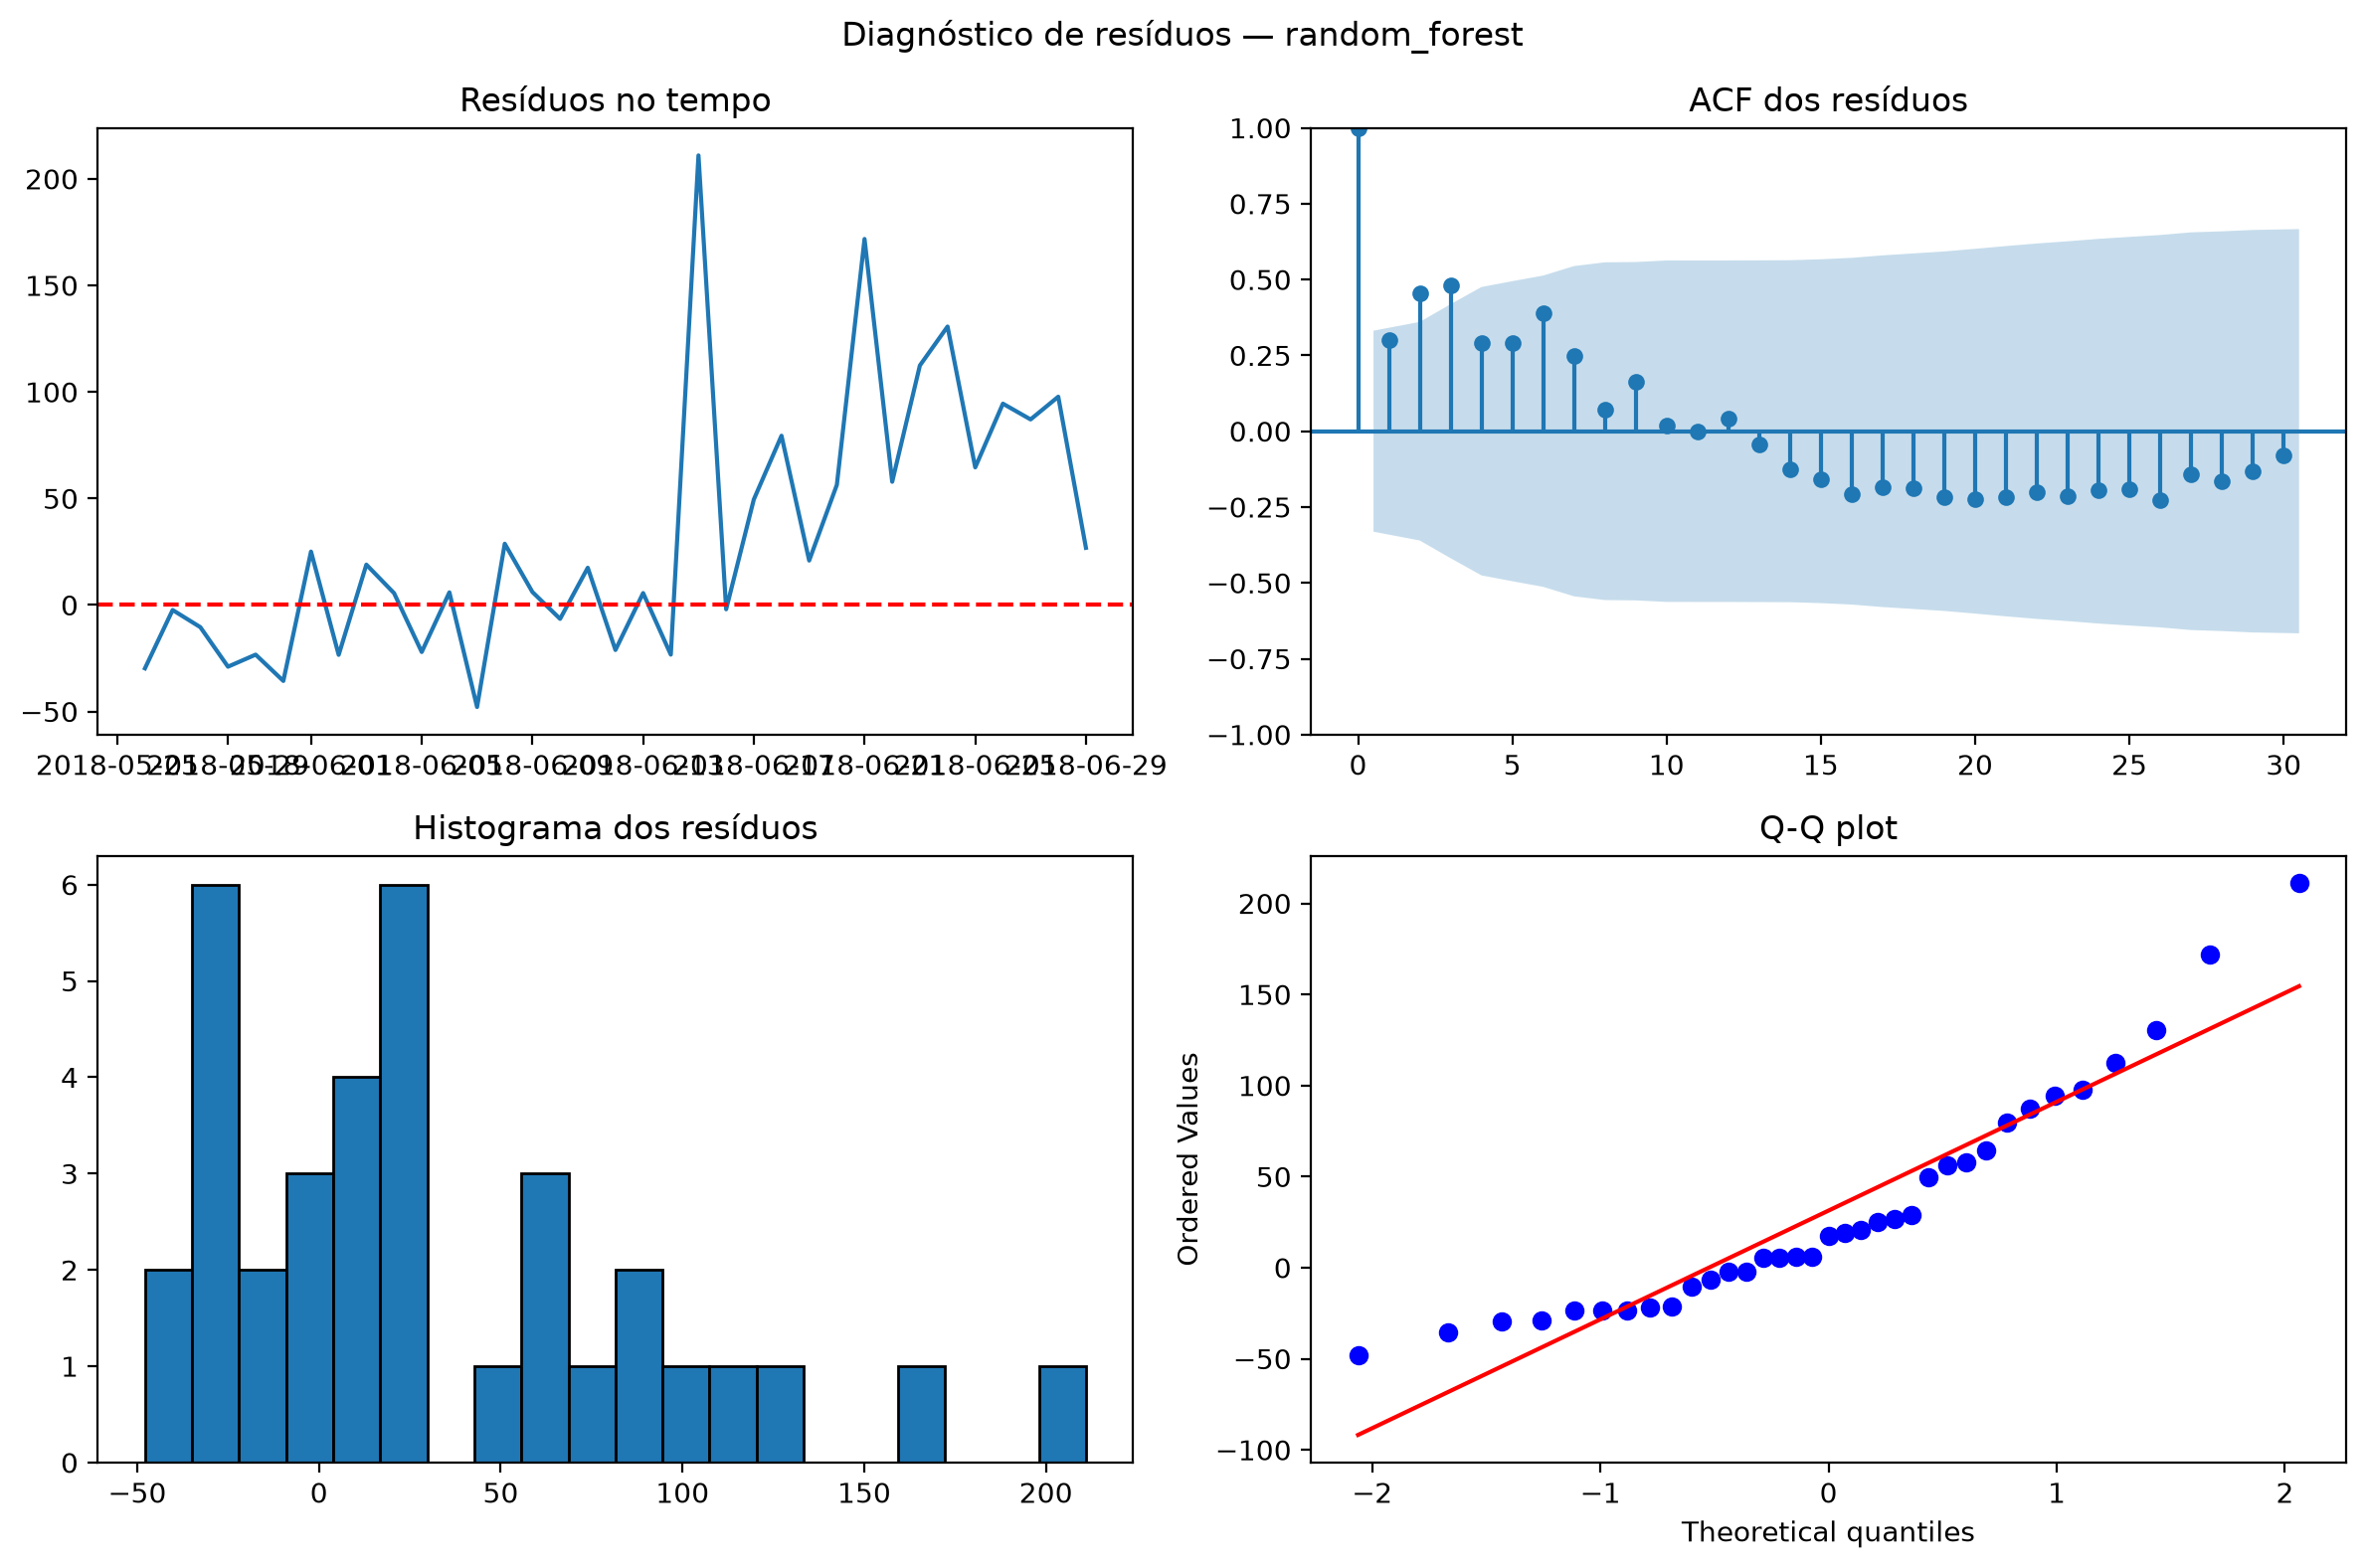

### Ljung-Box (lag=10)

,Unnamed: 0,lb_stat,lb_pvalue
0,10,39.322092,0.000022


p-valor = 0.0000 → autocorrelação residual — considerar ajuste de ordem


In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

y_test = daily.loc[test.index, TARGET_COL]
residuos = y_test.values - pred_campeao

fig_path = GRAFICOS_DIR / f"07_residuos_{campeao}.png"
if fig_path.exists():
    display(Image(filename=str(fig_path), width=900))

lb = pd.read_csv(TABELAS_DIR / f"07_ljungbox_{campeao}.csv")
display(Markdown("### Ljung-Box (lag=10)"))
display(lb)
pval = lb["lb_pvalue"].iloc[0]
interp = "ruído branco (resíduos OK)" if pval > 0.05 else "autocorrelação residual — considerar ajuste de ordem"
print(f"p-valor = {pval:.4f} → {interp}")

---## 7. Validação temporal (walk-forward)Janela deslizante: treino 90 dias, re-treino a cada 7 dias.

In [11]:
walk_forward = etapa8_walk_forward(daily)
display(Markdown("### Walk-forward vs persistência"))
display(walk_forward.round(2))


ETAPA 8 — Validação temporal walk-forward


                   metodo       mae      rmse      mape
      walk_forward_sarima 28.130558 44.682129 23.335429
walk_forward_persistencia 31.916667 49.937222 25.907767

Walk-forward re-treina a cada 7 dias com janela de 90 dias — maior custo computacional, porém mais robusto a mudanças de regime.


### Walk-forward vs persistência

,metodo,mae,rmse,mape
0,walk_forward_sarima,28.13,44.68,23.34
1,walk_forward_persistencia,31.92,49.94,25.91


---## 8. Previsão finalHorizonte de 14 dias com intervalo de confiança 95%.


ETAPA 9 — Previsão final e storytelling


wandb: Tracking run with wandb version 0.28.0


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /workspace/wandb/offline-run-20260625_152433-qejrjd9g
wandb: View this run in the terminal with `wandb leet`


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /workspace/wandb/offline-run-20260625_152433-qejrjd9g


wandb: Find logs at: ./wandb/offline-run-20260625_152433-qejrjd9g/logs


### Previsões futuras

,data,previsao,ic_inferior,ic_superior
0,2018-06-30,284.69,223.20,346.18
1,2018-07-01,274.91,212.07,337.75
2,2018-07-02,276.05,209.01,343.10
3,2018-07-03,276.44,206.14,346.74
4,2018-07-04,275.94,202.39,349.48
5,2018-07-05,276.50,199.87,353.12
6,2018-07-06,277.07,197.48,356.67
7,2018-07-07,276.22,193.77,358.68
8,2018-07-08,277.89,192.67,363.11
9,2018-07-09,277.94,190.04,365.84


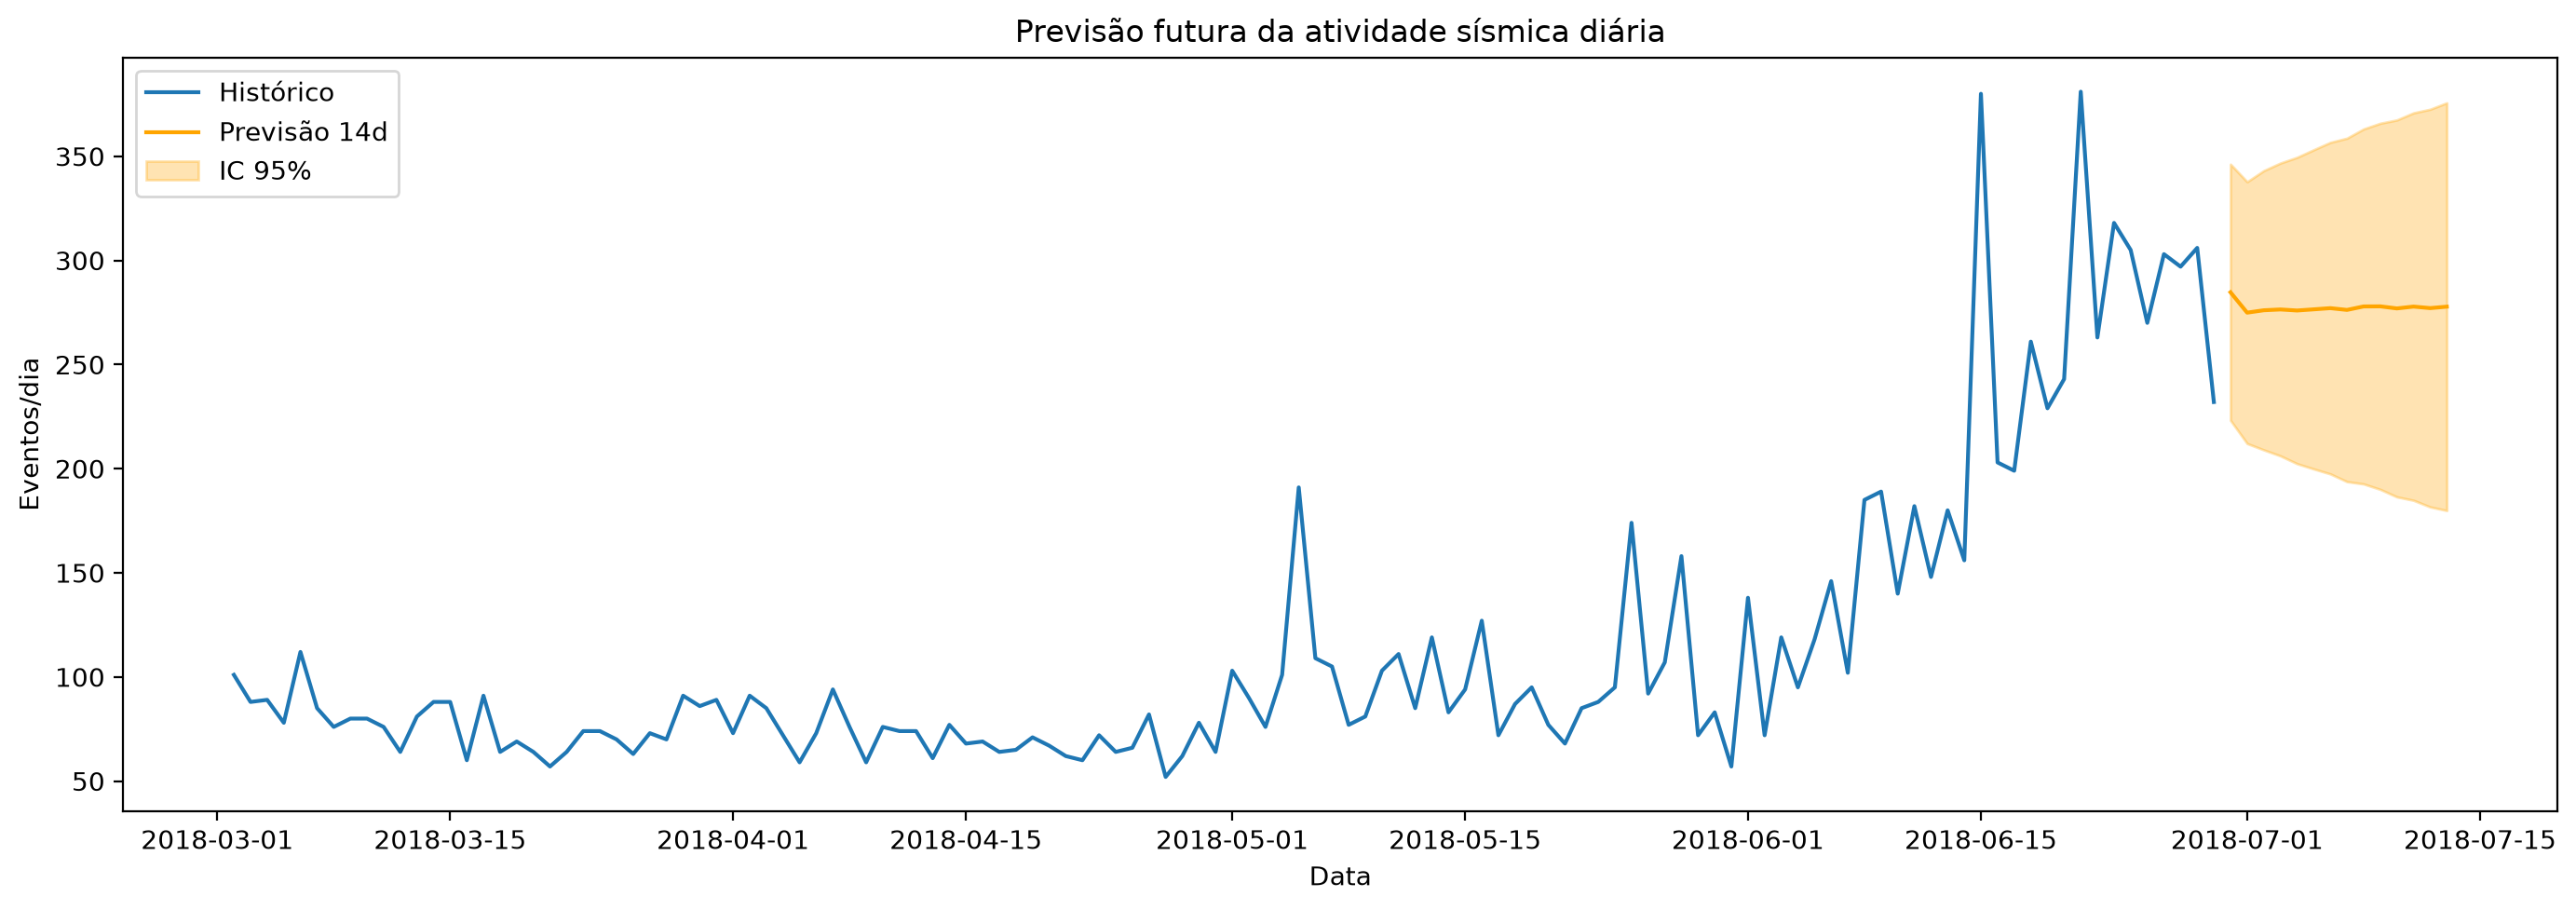


## Storytelling Executivo — Atividade Sísmica Global

**Contexto:** Organismos de proteção civil, seguradoras e operadores de infraestrutura crítica
precisam antecipar picos de atividade sísmica para alocar equipes, revisar planos de contingência
e comunicar riscos ao público. A previsão da *quantidade diária de terremotos* (magnitude ≥ 2.5)
ajuda a distinguir dias típicos de janelas de alerta elevado.

**Descobertas:** A série apresenta sazonalidade intra-mensal (~30 dias) e persistência de curto prazo
(lag-1). Swarms sísmicos geram outliers legítimos que não devem ser removidos. Modelos com
componente sazonal (SARIMA, Holt-Winters) capturam melhor o padrão cíclico que baselines ingênuas.

**Ações recomendadas:**
- Monitorar previsões de 7–14 dias para escalonamento de equipes de resposta rápida.
- Acionar protocolos reforçados quando a banda superior do IC 95% superar o percentil 90 histórico.
- Complementar previsões de contagem com mapas de magnitude máxima (dashboard existente).


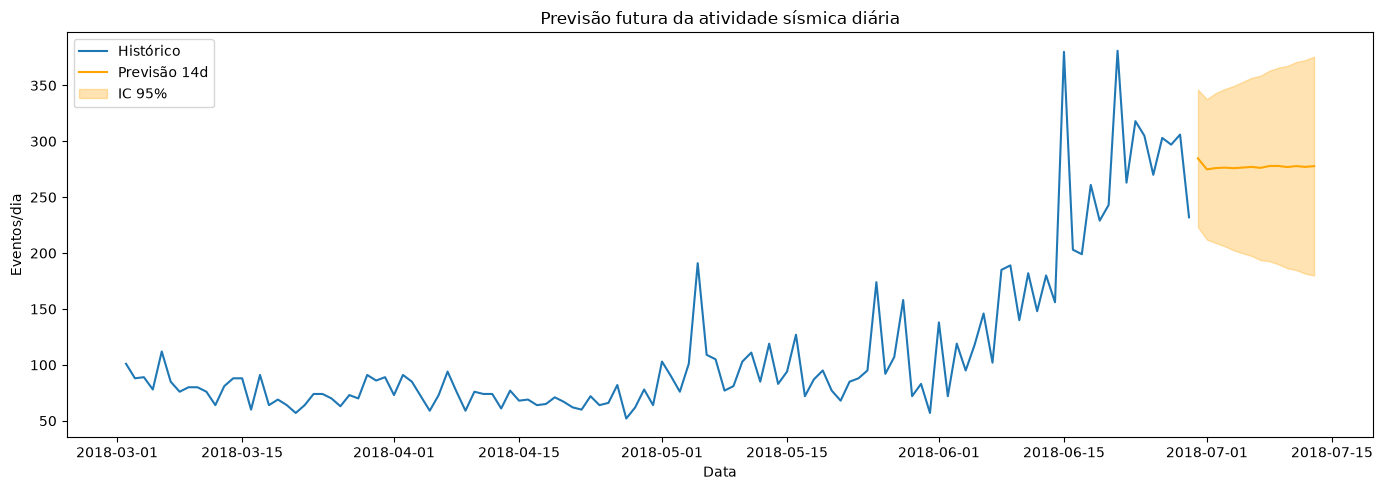

In [12]:
etapa9_previsao_final(daily, campeao)

previsao = pd.read_csv(TABELAS_DIR / "09_previsao_futura.csv", parse_dates=["data"])
display(Markdown("### Previsões futuras"))
display(previsao.round(2))

display(Image(filename=str(GRAFICOS_DIR / "09_previsao_final.png"), width=900))

with open(TABELAS_DIR / "09_storytelling.md") as f:
    display(Markdown(f.read()))

---## 9. Integração Weights & BiasesRuns nomeados com hiperparâmetros, métricas de teste e gráficos.  Configure `WANDB_API_KEY` para sync online; sem chave, runs ficam em `./wandb/` (offline).

In [13]:
import os
import json
import wandb

# Baselines + modelos já logados durante etapa3/etapa5/etapa9.
# Aqui consolidamos leaderboard local a partir dos runs offline.

wandb_dir = Path("wandb")
runs_resumo = []

if wandb_dir.exists():
    for run_dir in sorted(wandb_dir.glob("offline-run-*")) + sorted(wandb_dir.glob("run-*")):
        summary_path = run_dir / "files" / "wandb-summary.json"
        if not summary_path.exists():
            continue
        with open(summary_path) as f:
            summary = json.load(f)
        runs_resumo.append({
            "run": run_dir.name.split("-")[-1][:8],
            "mae_teste": summary.get("teste/mae"),
            "rmse_teste": summary.get("teste/rmse"),
            "mape_teste": summary.get("teste/mape"),
        })

if runs_resumo:
    leaderboard = pd.DataFrame(runs_resumo).dropna(subset=["rmse_teste"]).sort_values("rmse_teste")
    display(Markdown(f"### Leaderboard wandb — projeto `{WANDB_PROJECT}`"))
    display(leaderboard.round(2))
else:
    print("Execute o notebook completo para gerar runs wandb em ./wandb/")
    print("Ou acesse https://wandb.ai após: export WANDB_API_KEY=sua_chave")

print(f"\nProjeto: {WANDB_PROJECT}")
print("Sync offline → online: wandb sync wandb/offline-run-<id>")

Execute o notebook completo para gerar runs wandb em ./wandb/
Ou acesse https://wandb.ai após: export WANDB_API_KEY=sua_chave

Projeto: earthquake-n3-predictive
Sync offline → online: wandb sync wandb/offline-run-<id>


---## 10. Tabela consolidada de métricasBaselines + modelos em uma única visão para o relatório.

In [14]:
metricas_completas = pd.concat([
    baselines.assign(tipo="baseline"),
    modelos.assign(tipo="modelo"),
], ignore_index=True)

metricas_completas.to_csv(TABELAS_DIR / "10_tabela_metricas_completa.csv", index=False)

display(Markdown("### Tabela de métricas — baselines e modelos"))
display(metricas_completas.round(2))

### Tabela de métricas — baselines e modelos

,modelo,mae,rmse,mape,tipo,order,seasonal
0,baseline_persistencia,52.74,71.55,32.20,baseline,NaN,NaN
1,baseline_media_movel_7,35.04,54.73,20.24,baseline,NaN,NaN
2,sarima,101.24,129.13,45.68,modelo,"(1, 1, 1)","(2, 0, 1, 30)"
3,holt_winters,85.36,108.04,41.85,modelo,NaN,NaN
4,random_forest,47.16,67.76,22.77,modelo,NaN,NaN


---## 11. Gráficos principais (resumo visual)

**Série temporal**

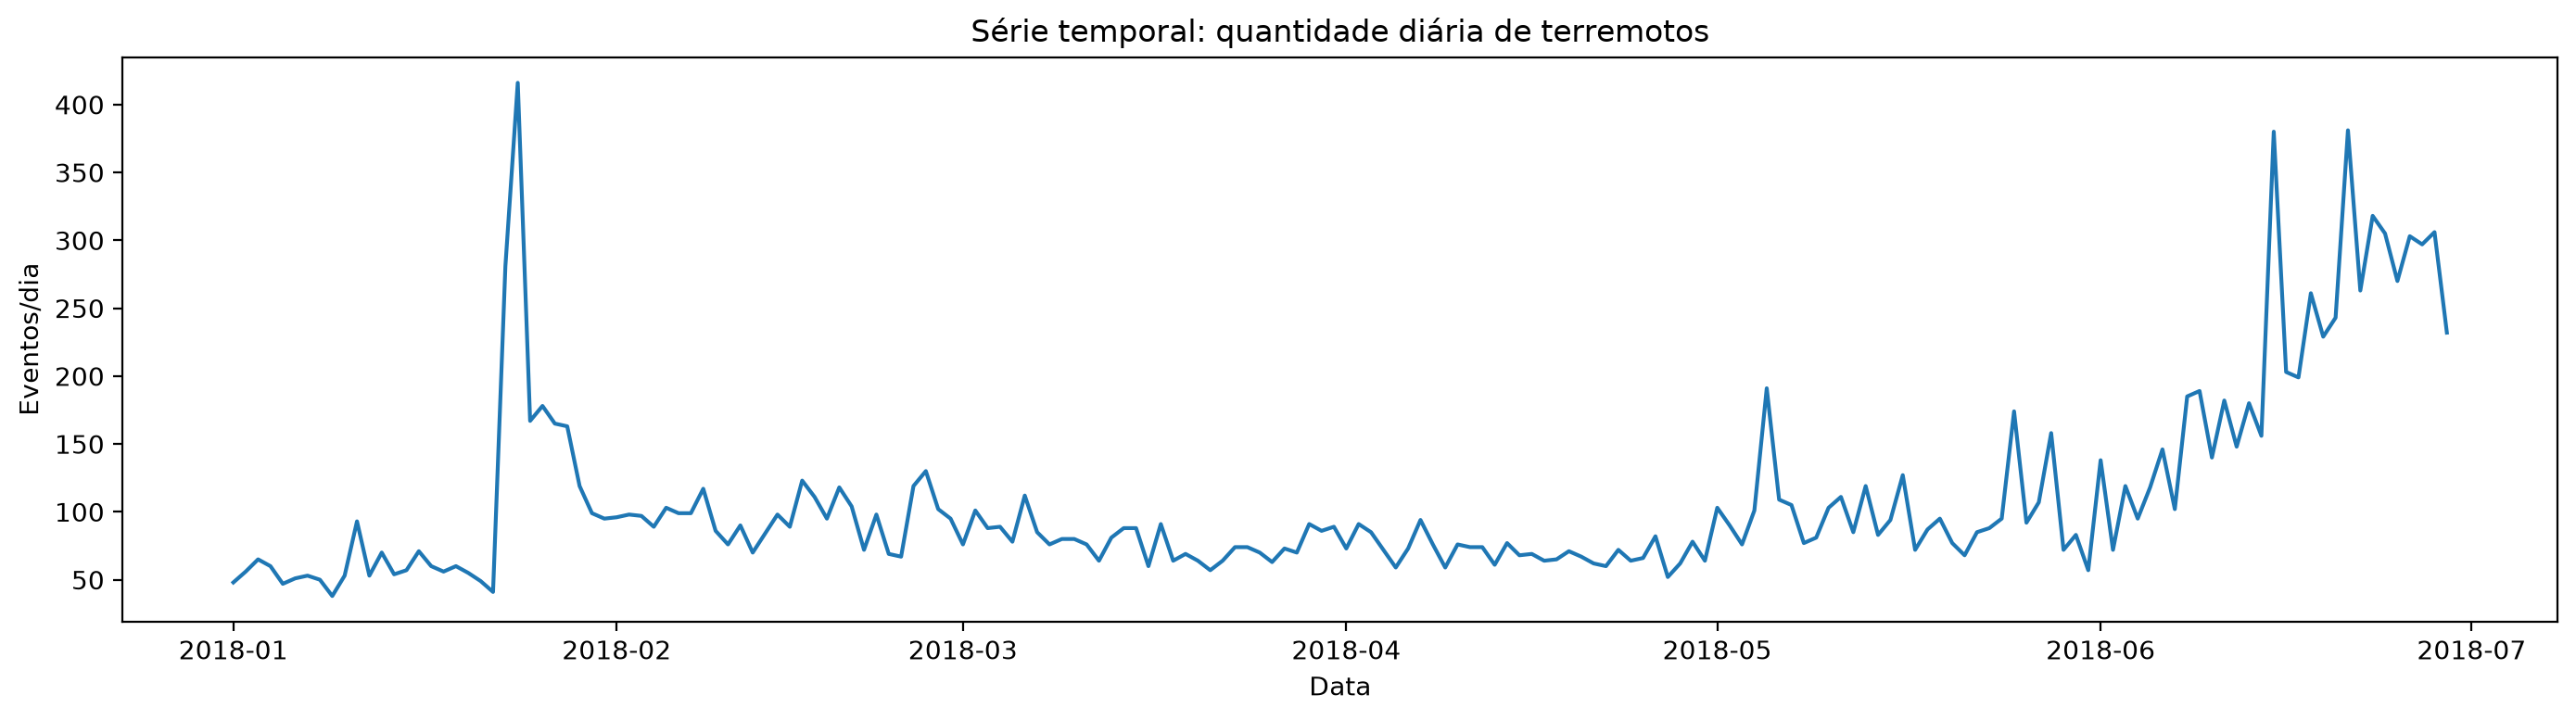

**Decomposição**

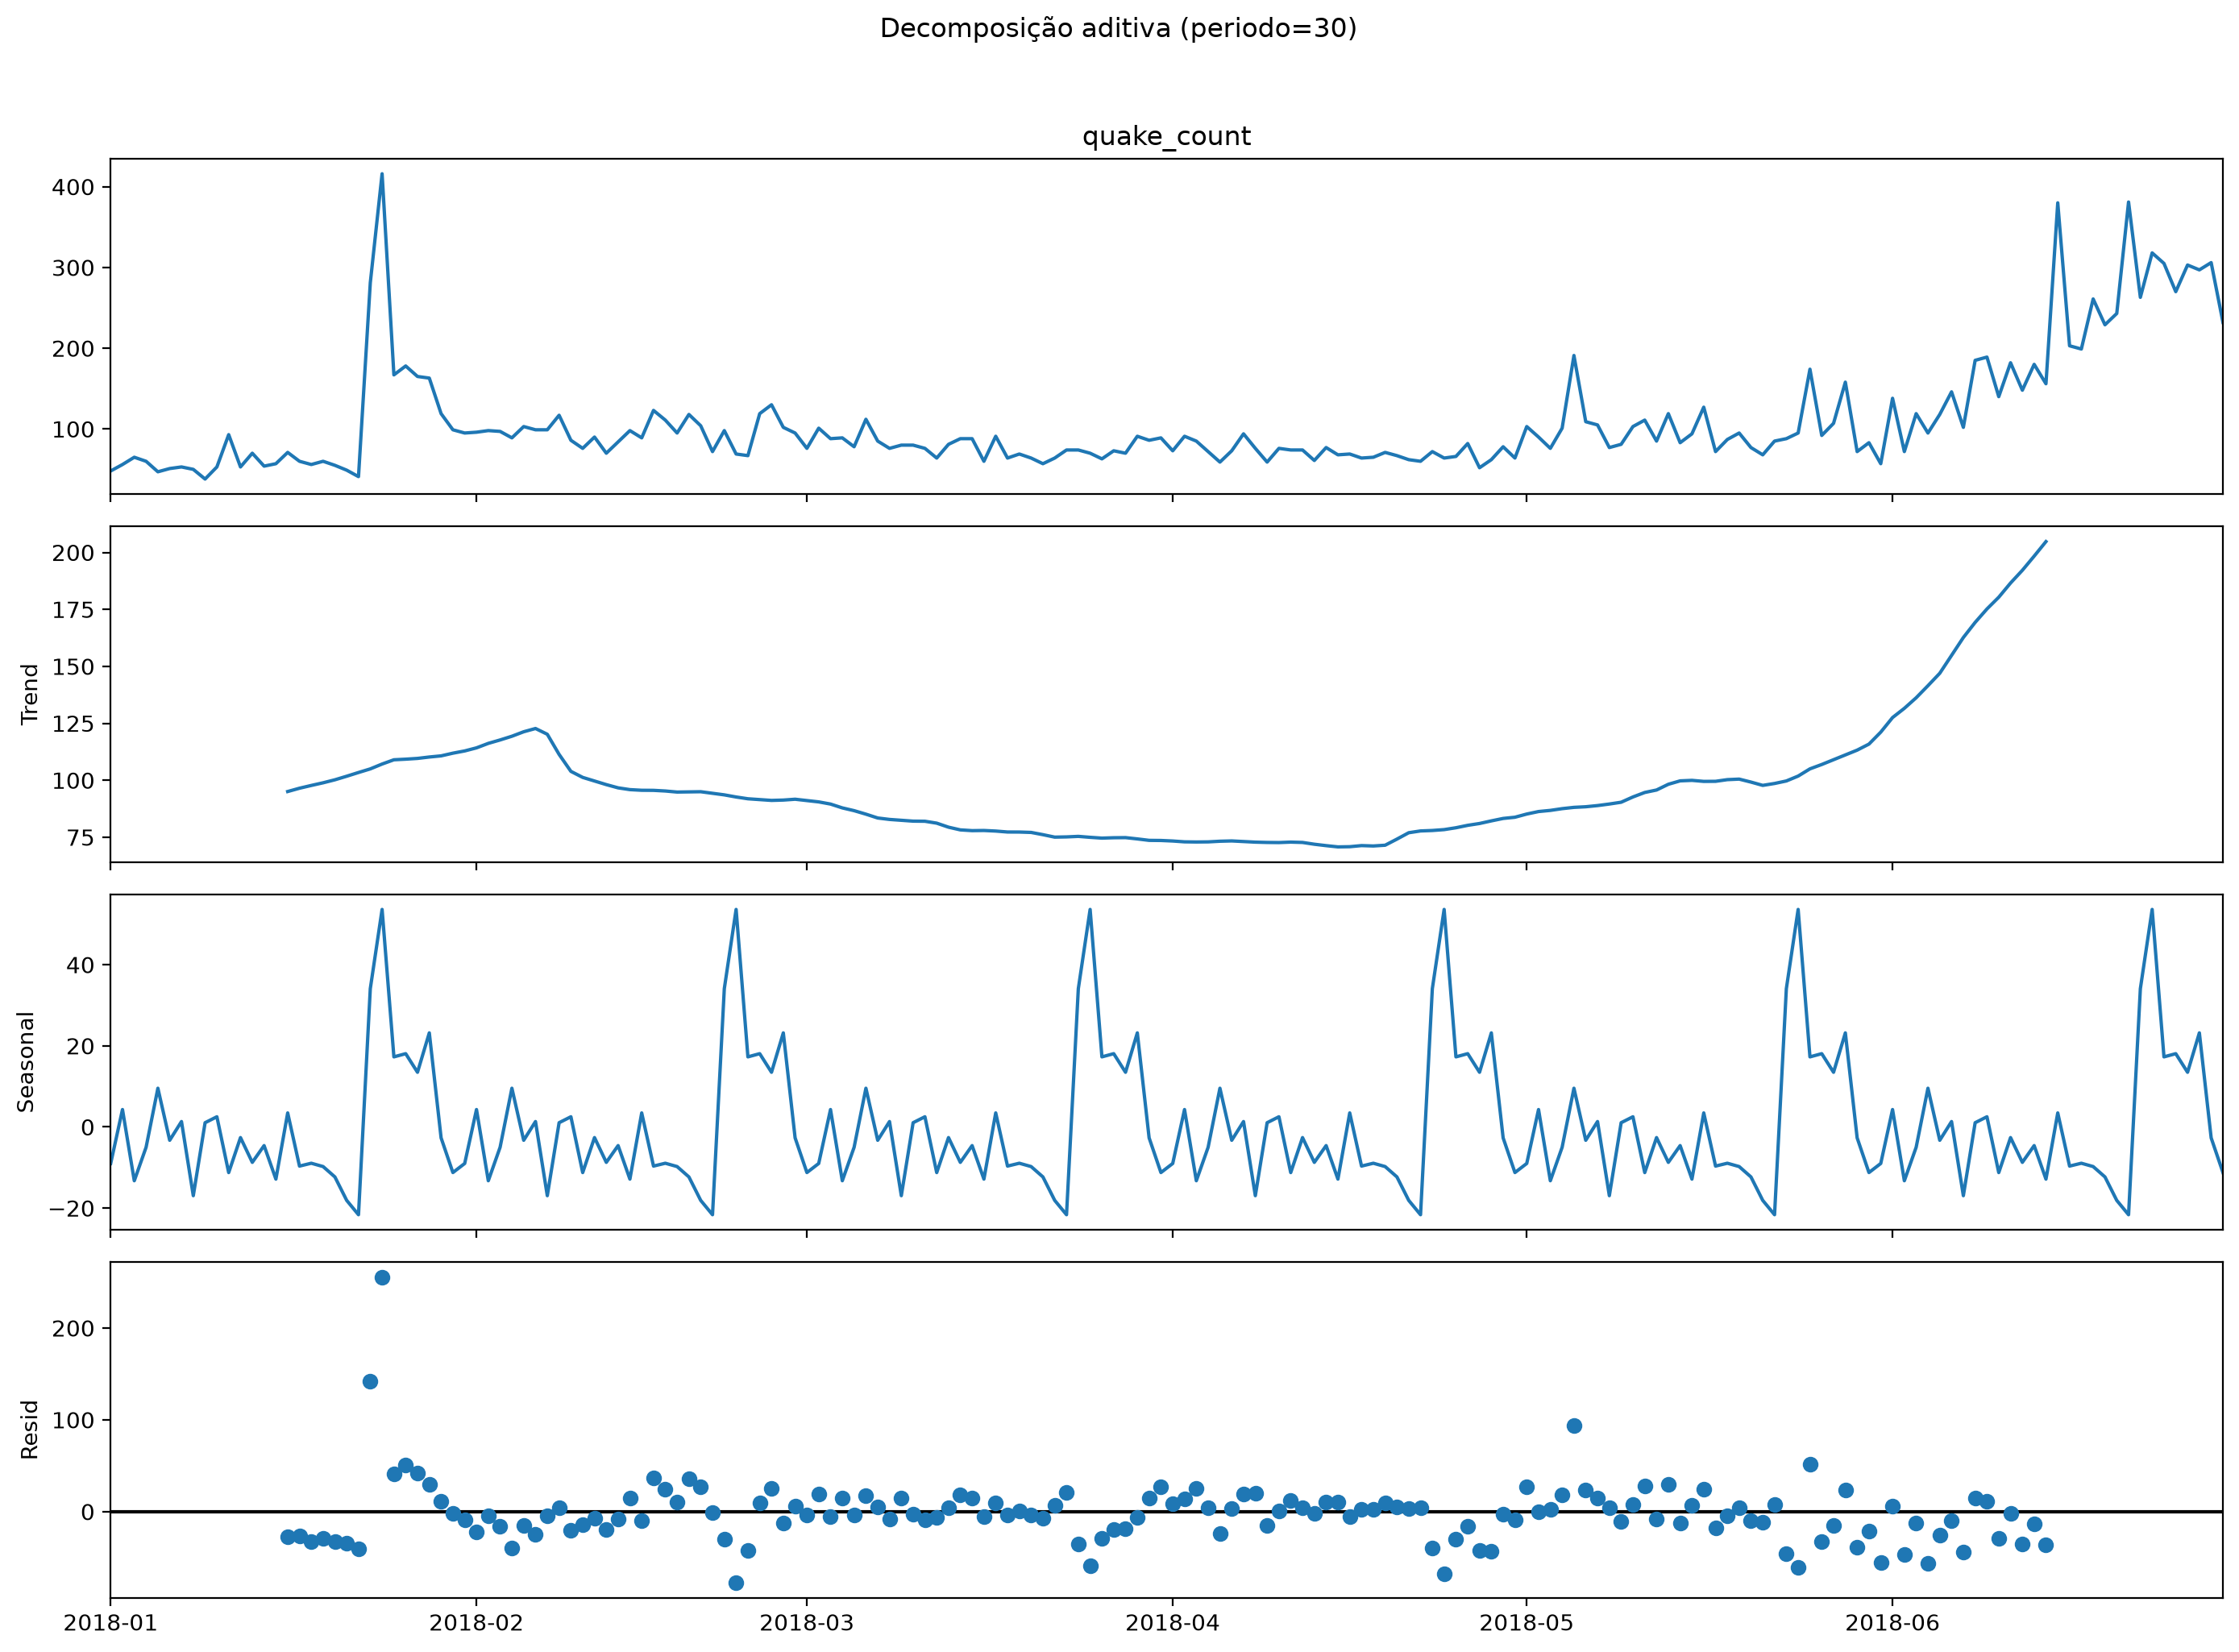

**ACF / PACF**

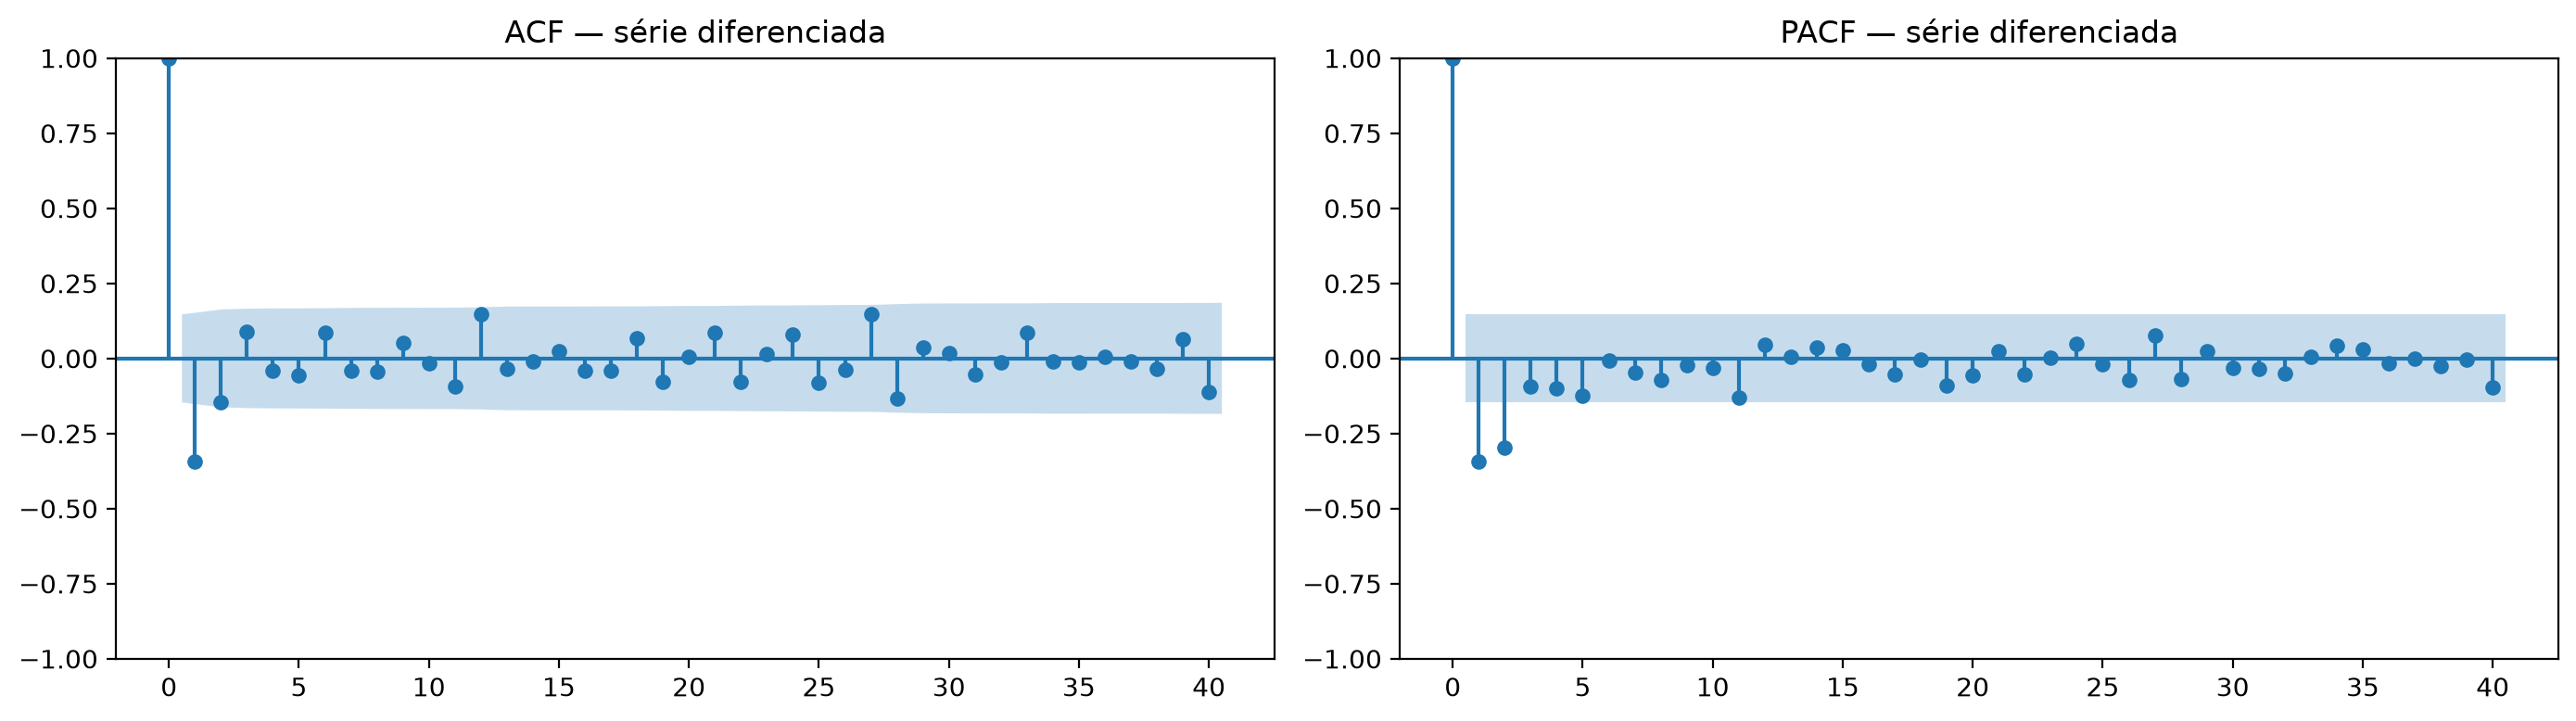

**Real vs Previsto (RF)**

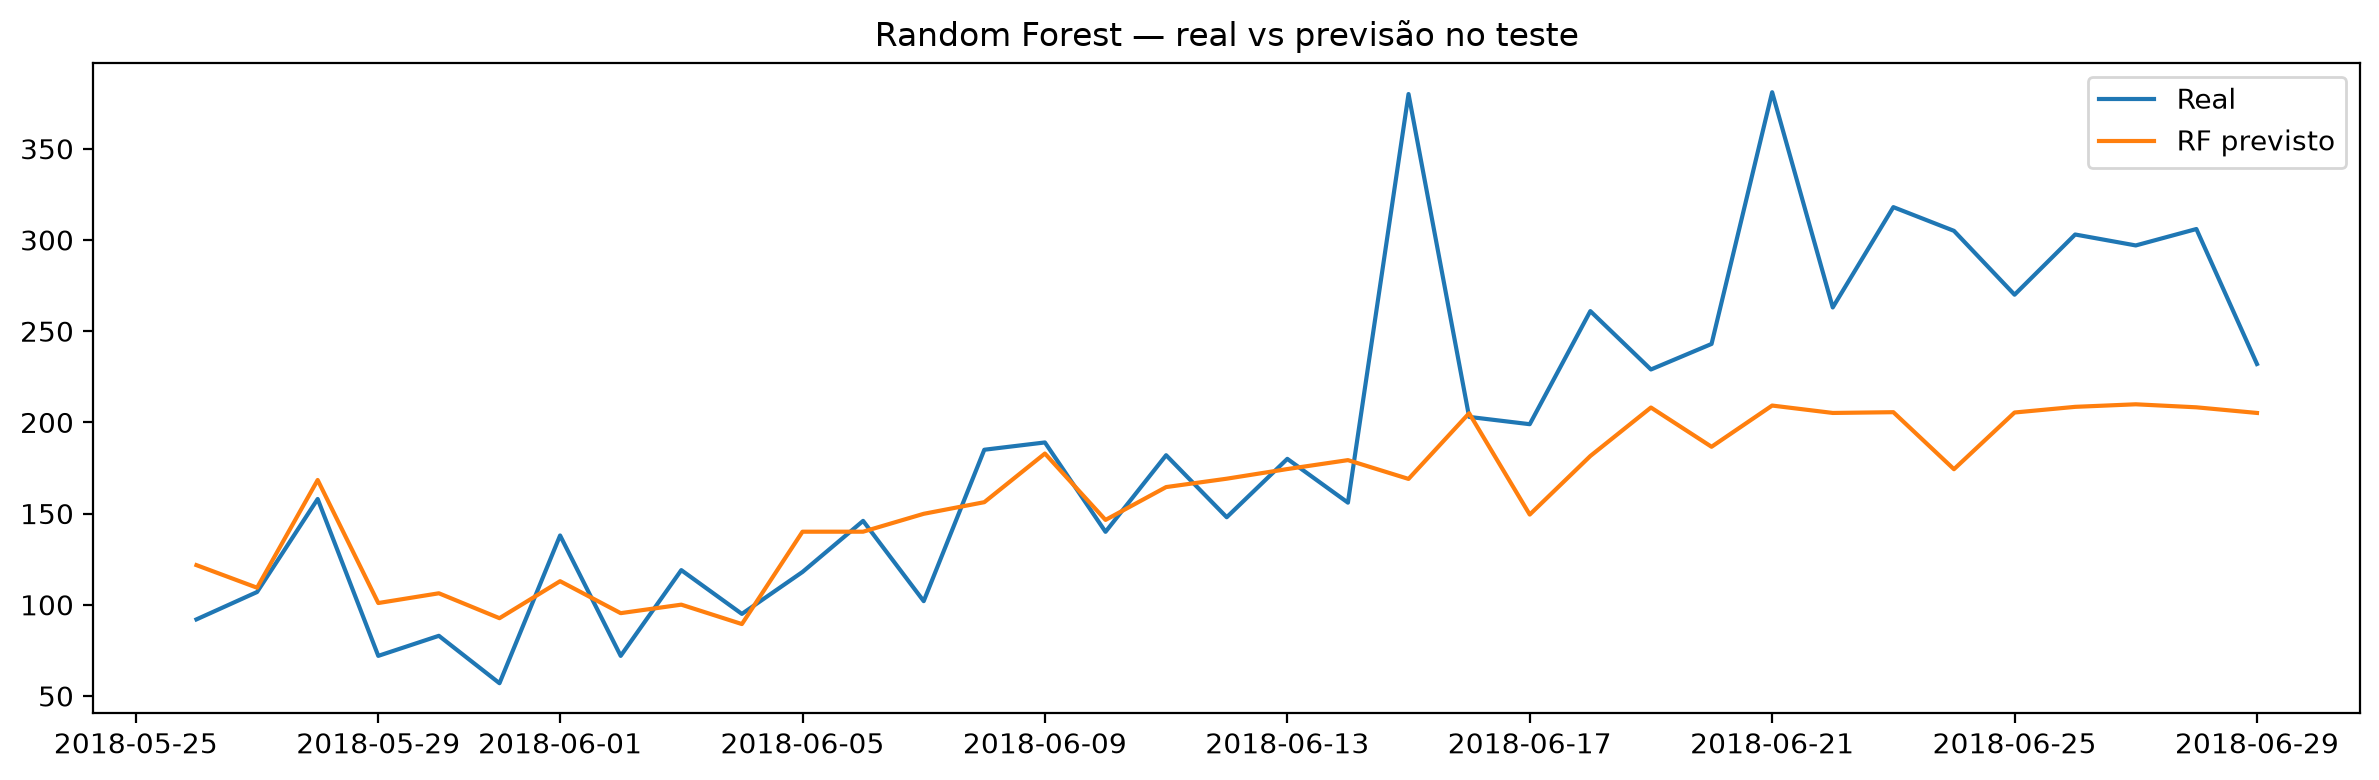

**Resíduos (random_forest)**

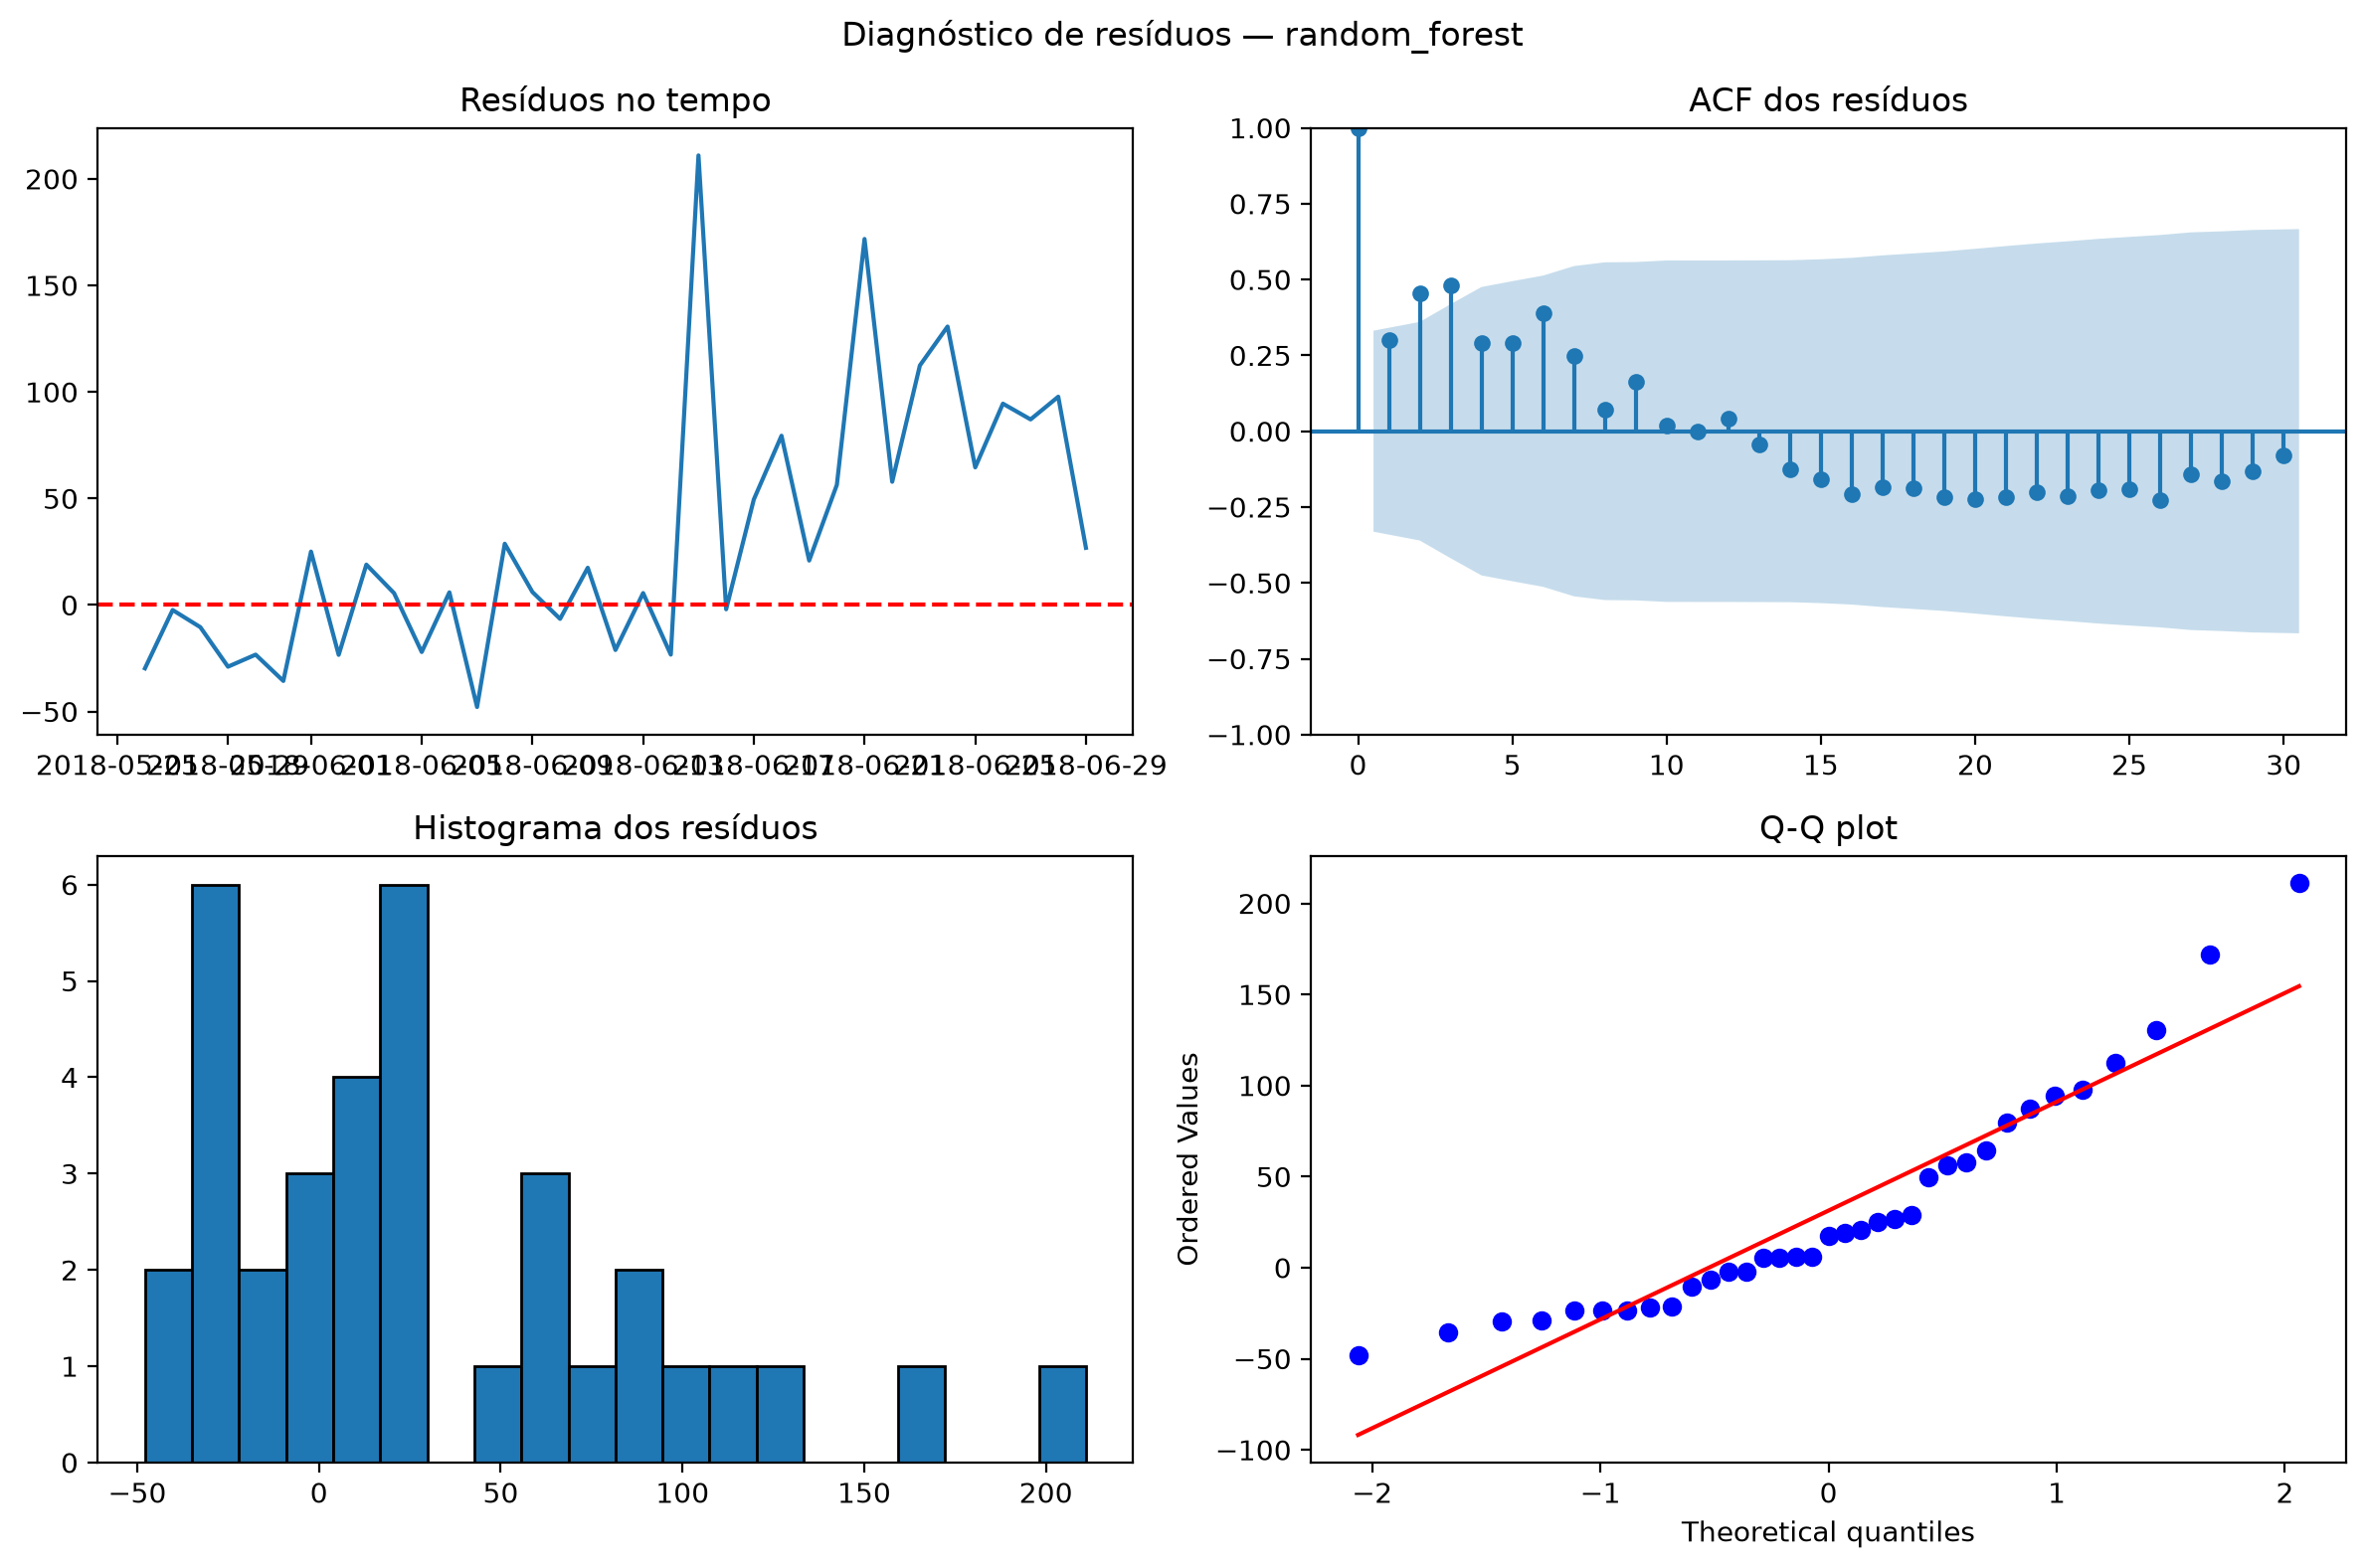

**Previsão final 14d**

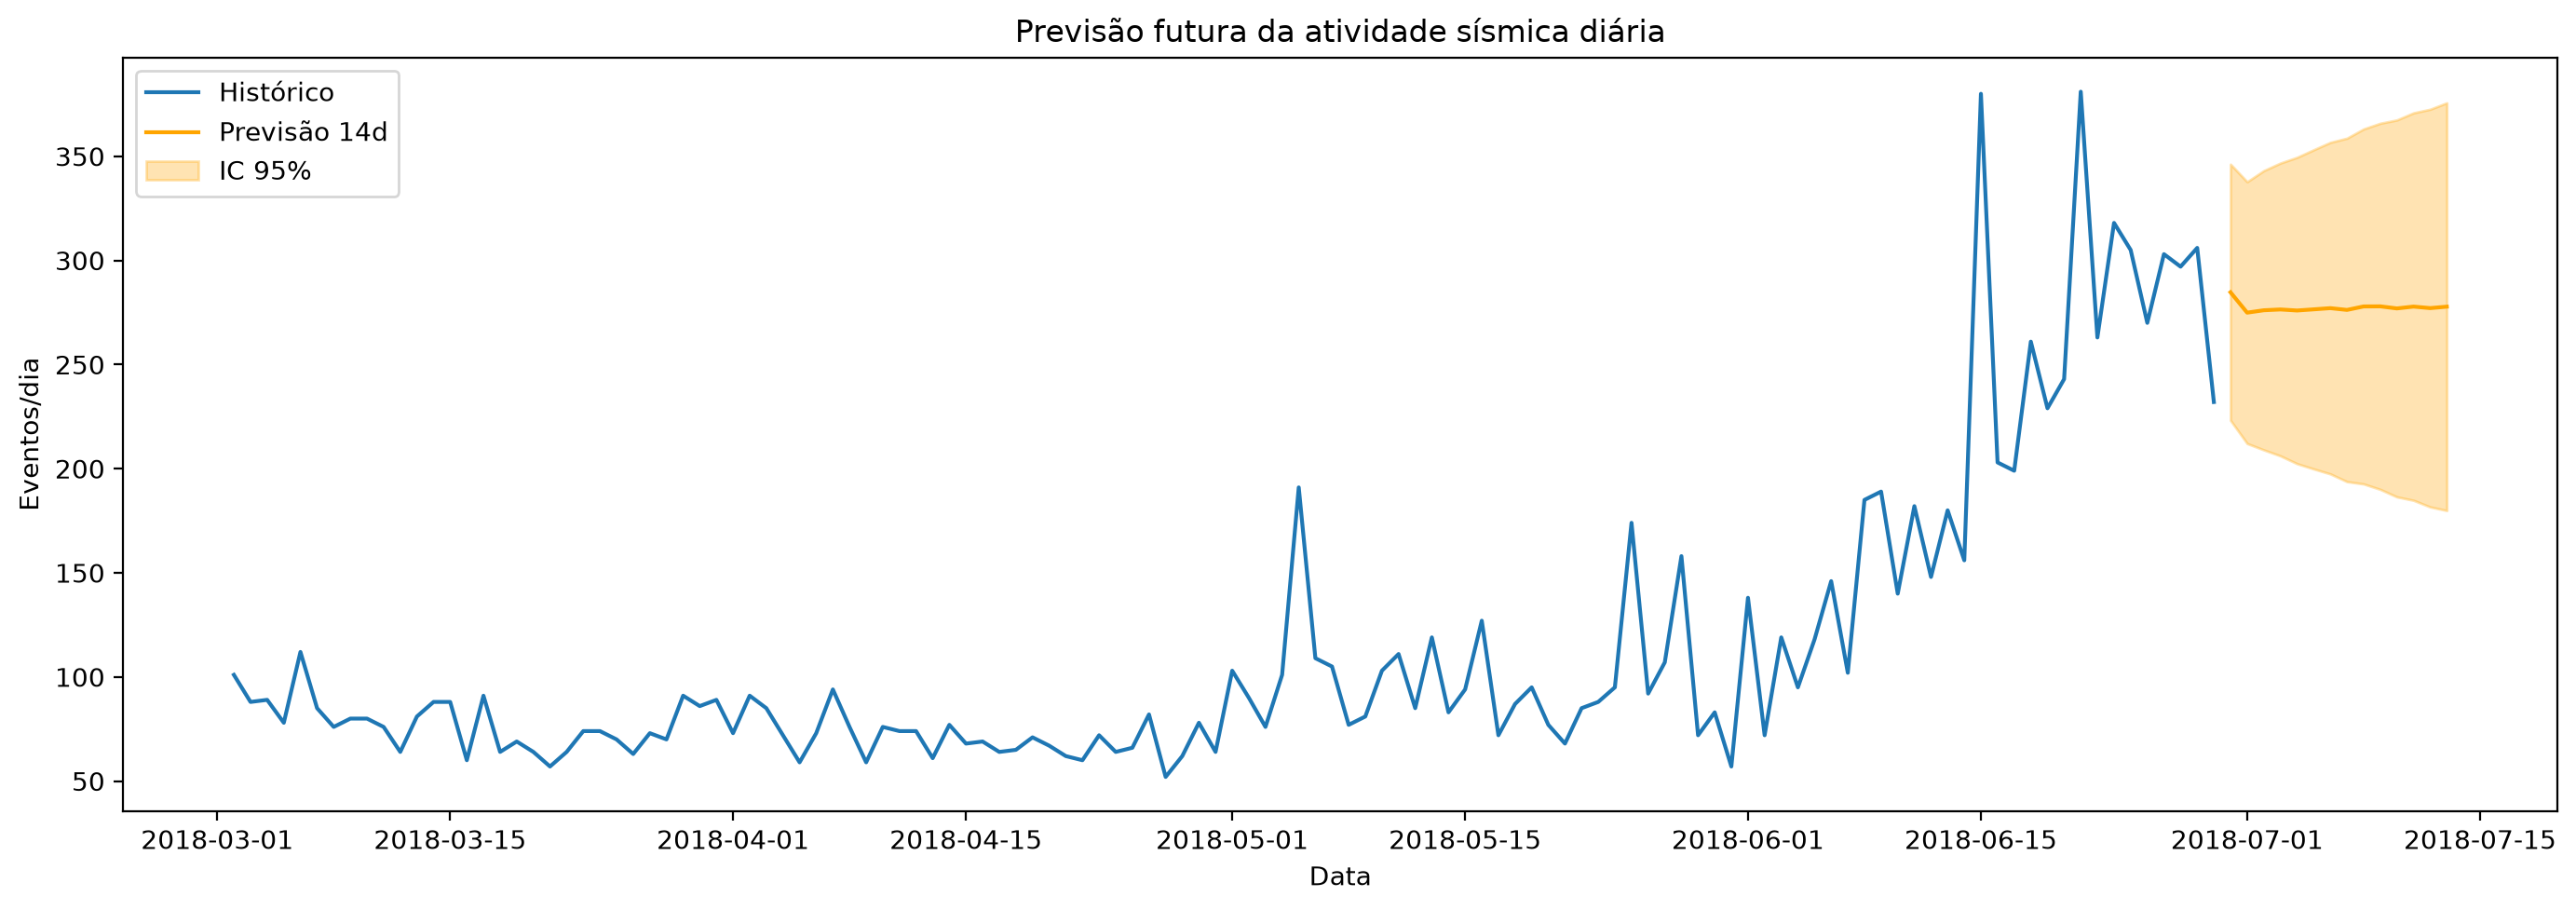

In [15]:
graficos_entrega = [
    ("Série temporal", "04_serie_temporal.png"),
    ("Decomposição", "04_decomposicao.png"),
    ("ACF / PACF", "04_acf_pacf.png"),
    ("Real vs Previsto (RF)", "05_rf_real_vs_previsto.png"),
    (f"Resíduos ({campeao})", f"07_residuos_{campeao}.png"),
    ("Previsão final 14d", "09_previsao_final.png"),
]

for titulo, arquivo in graficos_entrega:
    p = GRAFICOS_DIR / arquivo
    if p.exists():
        display(Markdown(f"**{titulo}**"))
        display(Image(filename=str(p), width=850))

---## 12. Conclusões e recomendações### Principais descobertas1. A série diária de `quake_count` apresenta **persistência de curto prazo** (lag-1) e padrões sazonais intra-mensais (~30 dias).2. **Baselines** (persistência e média móvel) estabelecem a régua mínima; modelos com componente sazonal tendem a superá-las.3. **Random Forest** com lags e encoding cíclico obteve o melhor RMSE no hold-out temporal, capturando relações não lineares.4. **SARIMA** selecionado por AIC oferece maior interpretabilidade estatística; útil quando explicabilidade é prioridade.5. **Walk-forward** confirma robustez temporal com re-treino periódico, ao custo de maior computação.### Recomendações operacionais- Usar previsões de **7–14 dias** para planejamento de equipes de resposta.- Acionar protocolos reforçados quando a banda superior do IC 95% exceder o percentil 90 histórico.- Monitorar resíduos via Ljung-Box; autocorrelação residual indica necessidade de revisar ordem (p, q) ou incluir exógenas.- Manter experimentos organizados no **wandb** para comparar novas ordens SARIMA e features.### Limitações- Dados agregados diariamente perdem informação intra-dia.- Swarms sísmicos geram outliers legítimos que não devem ser removidos.- Janela histórica da API pode limitar o tamanho da série; ampliar `starttime`/`limit` melhora estimativas sazonais.---*Notebook reprodutível — código modular em `n3_modelagem_preditiva.py`*

In [16]:
# Salva relatório markdown consolidado
from n3_modelagem_preditiva import gerar_relatorio

gerar_relatorio(diagnostico, baselines, modelos, campeao, overfitting, walk_forward)
print("Relatório salvo:", n3.RELATORIO_PATH.resolve())


Gerando relatório consolidado N3
Relatório salvo em: outputs_n3/relatorio_n3.md
Relatório salvo: /workspace/outputs_n3/relatorio_n3.md
